# Linear Regression — Complete Machine Learning Project

### Predicting Flight Arrival Delay from Operational and Passenger Data

**Series:** AI/ML Engineering Learning Series
**Notebook:** 03 — Linear Regression (Theory + Full Professional Workflow)
**Author:** *(your name)*
**Prerequisite notebooks:** NumPy, Pandas, Matplotlib/Seaborn fundamentals

---

## 1. Project Overview

This notebook is a complete, self-contained study of **Linear Regression**, covering both the
underlying mathematics and a full production-style machine learning workflow applied to a real
dataset.

The purpose of this notebook is not to produce the highest possible R² score. The purpose is to
practice the reasoning that a machine learning engineer applies at every stage of a regression
project: understanding the data before touching it, justifying every preprocessing decision,
checking the assumptions behind the model instead of trusting the output blindly, comparing models
honestly instead of picking the one with the best training score, and being explicit about what the
final numbers do and do not mean.

Every major step below follows the same pattern:

1. **What** we are doing.
2. **Why** we are doing it.
3. **What the output tells us.**
4. **What decision we make** as a result.

Where a standard technique from the regression workflow does not apply well to this particular
dataset (for example, a time-aware split, or heavy imputation), the notebook still explains the
technique in full — what it is, when it is normally needed, why it is not needed here, and what
would go wrong if it were applied anyway. The goal is to leave this notebook able to run the entire
workflow on a *different* dataset, not just this one.

## 2. Problem Definition

### 2.1 The dataset in plain terms

The dataset used in this notebook is a large **airline passenger satisfaction survey**
(129,880 records). For every passenger, it records demographic information, trip information,
ratings of thirteen aspects of the flight experience (Wi-Fi, seat comfort, boarding, cleanliness,
etc.), the number of minutes the flight **departed** late, the number of minutes the flight
**arrived** late, and whether the passenger reported being "satisfied" overall.

### 2.2 Why this notebook does not predict "satisfaction"

The column that looks like the obvious target at first glance, `satisfaction`, is a **binary label**
(`True` / `False`). Predicting a binary outcome is a **classification** problem, not a regression
problem, and Linear Regression is the wrong tool for it (fitting a straight line to a 0/1 outcome
produces predictions that are not probabilities and are not bounded between 0 and 1 — that is what
Logistic Regression is for). Part 1 below walks through this reasoning in detail before a target is
chosen.

Once `satisfaction` is set aside, the dataset contains a genuinely continuous, real-world quantity
that airlines care about operationally: **`Arrival Delay in Minutes`**. This becomes the target of
this notebook.

### 2.3 Real-world framing

**Problem statement:** *Given information that is known about a flight and its passenger at, or
shortly after, departure — including how late the flight already left the gate — predict how many
minutes late the flight will arrive at its destination.*

- **Who would use this model:** an airline's operations team (to proactively rebook connections or
  notify passengers), or a customer-facing app that wants to show an estimated arrival delay before
  the flight lands.
- **Information available to the model (X):** passenger demographics, trip attributes (class,
  travel type, flight distance), in-flight service ratings, and the departure delay already
  observed.
- **What the model predicts (y):** `Arrival Delay in Minutes` — a continuous, non-negative number.
- **Why this is regression, not classification:** the target is a continuous measurement (minutes),
  not a category. There is no fixed, small set of classes; the outcome can take on any non-negative
  value, and the *distance* between two predictions is meaningful (predicting 40 minutes when the
  true delay is 45 is a much better prediction than predicting 5 minutes).

**Classification vs. Regression — a simple example:**

| Question | Task type | Example output |
|---|---|---|
| "Will this flight arrive **late**?" (yes/no) | Classification | `True` / `False` |
| "**How many minutes** late will this flight arrive?" | Regression | `18.4` |

Both questions can be asked of the same flight, but they require different models, different loss
functions, and different evaluation metrics. This notebook focuses exclusively on the second
question.

**Formal definition:**

- **Input (X):** 20 features — 4 categorical (`Gender`, `Customer Type`, `Type of Travel`, `Class`)
  and 16 numerical (`Age`, `Flight Distance`, 13 service-rating scores, `Departure Delay in
  Minutes`).
- **Output (y):** `Arrival Delay in Minutes` (continuous, minutes, minimum 0).
- **ML Task:** Supervised regression.

## 3. Dataset Description

| Property | Value |
|---|---|
| Source file | `data.csv` |
| Rows | 129,880 |
| Columns | 22 |
| Target (selected) | `Arrival Delay in Minutes` |
| Excluded label | `satisfaction` (binary — reserved for a classification project) |
| Missing values | 393 rows missing the target (0.30%); no missing values elsewhere |
| Duplicate rows | 0 |
| Categorical features | `Gender`, `Customer Type`, `Type of Travel`, `Class` |
| Numerical features | `Age`, `Flight Distance`, 13 service-rating scores (ordinal 1–5), `Departure Delay in Minutes` |

The full inspection that produced this table — including *why* each decision was made — is carried
out from first principles in Part 8 onward. This table is a preview, not a substitute for the
inspection.

## 4. Linear Regression Theory

This section builds the theory from the ground up before any code touches the dataset. If you
already feel comfortable with a subsection, skim it — but do not skip Section 4.7 (Gradient Descent
vs. OLS) or Section 4.8 (coefficient interpretation), since misunderstandings there are extremely
common even among practitioners who use `LinearRegression()` every day.

### 4.1 Definition

**Linear Regression** models the relationship between one or more input variables (features) and a
continuous output variable (target) as a **weighted sum of the inputs plus a constant offset**. The
model assumes that, on average, the target changes by a constant amount for every one-unit change in
a feature, regardless of the value of that feature (this is the "linear" part of the name — linear in
the parameters, not necessarily in a straight-line sense of the raw features, see Part 37 on
polynomial regression).

Its purpose is twofold, and the two purposes pull in slightly different directions:

1. **Prediction** — produce a numeric estimate of the target for new, unseen inputs.
2. **Inference** — quantify and explain *how* each input is associated with the target (the
   coefficients).

This notebook uses Linear Regression primarily for prediction, but Parts 15–20 treat it carefully
enough to discuss inference as well, because that is where most of the model's real statistical
assumptions matter.

### 4.2 Simple Linear Regression

With a single feature $x$, the model is:

$$\hat{y} = \beta_0 + \beta_1 x$$

| Symbol | Meaning |
|---|---|
| $\hat{y}$ | the model's **predicted** value of the target (a "hat" always denotes a prediction, not the true value) |
| $\beta_0$ | the **intercept** — the predicted value of $y$ when $x = 0$ |
| $\beta_1$ | the **coefficient** (slope) — how much $\hat{y}$ changes for a one-unit increase in $x$ |
| $x$ | the input feature |

**Intuitive example:** suppose a very simple (hypothetical) model predicts arrival delay purely from
departure delay: $\hat{y} = 1.5 + 0.95x$. A flight that departed 20 minutes late would be predicted
to arrive $1.5 + 0.95 \times 20 = 20.5$ minutes late. The coefficient $0.95$ says that, in this
simplified single-feature model, each extra minute of departure delay is associated with roughly
0.95 extra minutes of arrival delay. The intercept $1.5$ says that even a flight that departs exactly
on time ($x=0$) is predicted to arrive about 1.5 minutes late on average, perhaps reflecting typical
minor delays picked up during taxiing, air traffic, or landing queues.

### 4.3 Multiple Linear Regression

With $n$ features, the model generalizes to:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Each feature $x_i$ has its own coefficient $\beta_i$. The prediction is the sum of the intercept and
every feature's individual contribution. In matrix form, if $X$ is the matrix of all observations and
features (with a column of 1s prepended for the intercept) and $\beta$ is the vector of all
coefficients, this is written compactly as:

$$\hat{y} = X\beta$$

This is the form scikit-learn actually solves internally, and it is revisited in the mathematical
summary (Part 41).

### 4.4 Residuals

The **residual** for observation $i$ is the difference between what actually happened and what the
model predicted:

$$e_i = y_i - \hat{y}_i$$

| Residual | Meaning |
|---|---|
| Positive ($e_i > 0$) | The model **underpredicted** — the actual delay was higher than predicted |
| Negative ($e_i < 0$) | The model **overpredicted** — the actual delay was lower than predicted |
| Small $\lvert e_i \rvert$ | The prediction was close to reality for that observation |
| Large $\lvert e_i \rvert$ | The prediction was far from reality — worth investigating (Part 27) |

Residuals are the raw material for almost every diagnostic performed later in this notebook
(Parts 17–20). A model that fits well has residuals that are small and show no obvious pattern when
plotted against predictions or against individual features.

### 4.5 Cost Function — Mean Squared Error

To fit the model, we need a single number that summarizes "how wrong" a given set of coefficients
is across the whole training set. Linear Regression uses the **Mean Squared Error (MSE)**:

$$\text{MSE}(\beta) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 = \frac{1}{n}\sum_{i=1}^{n} e_i^2$$

**Why squares, and not absolute values or raw residuals?**

- Squaring makes every term **non-negative**, so positive and negative residuals cannot cancel out
  and hide the true error (summing raw residuals could total zero even for a terrible model).
- Squaring is **differentiable everywhere**, including at zero, which allows the minimum to be found
  analytically (Section 4.6) or via calculus-based optimization (Section 4.7). The absolute value
  used in MAE is not differentiable at zero, which makes it harder to optimize directly, although
  it is still an excellent *evaluation* metric (Part 15).
- Squaring **penalizes large errors disproportionately more than small ones**. A residual of 20 is
  penalized 4 times more than a residual of 10, not just twice as much. This is a deliberate design
  choice: it makes the model more sensitive to large misses, which is desirable in many settings but
  also means MSE-based models can be pulled around by a small number of extreme values (this becomes
  very relevant in Part 20, since this dataset's target has a long right tail).

### 4.6 Ordinary Least Squares (OLS)

**Ordinary Least Squares** is the method used to find the specific coefficients $\beta$ that
minimize the MSE (equivalently, the sum of squared residuals, since MSE is just that sum divided by
a constant $n$):

$$\hat{\beta} = \arg\min_{\beta} \sum_{i=1}^{n}\left(y_i - X_i\beta\right)^2$$

Because MSE is a smooth, convex (bowl-shaped) function of $\beta$, it has exactly one minimum, and
calculus gives us a **closed-form formula** for it directly, without any iterative search:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

**Intuition:** picture plotting the sum of squared residuals as a function of the coefficients — for
one coefficient, this is a parabola; for many coefficients, it is a smooth, bowl-shaped surface in
many dimensions. Because the surface is convex, its lowest point is unique, and taking the gradient
of this surface with respect to $\beta$ and setting it to zero gives the equation above directly.
This is exactly what scikit-learn's `LinearRegression()` computes under the hood (it does not
"search" for the answer — it computes it directly using linear algebra, typically via a numerically
stable decomposition such as SVD rather than literally inverting $X^TX$, but the result is
mathematically the same closed-form solution).

### 4.7 Gradient Descent (and why `LinearRegression()` does not use it)

**Gradient Descent** is a general-purpose iterative optimization algorithm. It is worth understanding
even though it is *not* what scikit-learn's `LinearRegression` uses, because (a) it is the
foundation of how neural networks and many other models are trained, and (b) some large-scale linear
model implementations (e.g. `SGDRegressor`) do use it.

The idea:

1. Start with random (or zero) coefficients $\beta$.
2. Compute the **gradient** of the loss function (MSE) with respect to $\beta$ — the direction in
   which the loss increases fastest.
3. Take a small step in the **opposite** direction (downhill), scaled by a **learning rate** $\alpha$:

$$\beta \leftarrow \beta - \alpha \cdot \nabla_{\beta}\,\text{MSE}(\beta)$$

4. Repeat steps 2–3 for many iterations, until the loss stops decreasing meaningfully (convergence).

| Term | Meaning |
|---|---|
| Loss function | The quantity being minimized (MSE, in this case) |
| Gradient | The vector of partial derivatives of the loss with respect to each coefficient — it points "uphill" |
| Learning rate ($\alpha$) | How large a step to take at each iteration; too large can overshoot and diverge, too small converges slowly |
| Parameter update | The rule that adjusts $\beta$ at each step, shown above |
| Local / global minimum | For plain Linear Regression the MSE surface is convex, so there is only **one** minimum, and it is both local and global — gradient descent (with a sensible learning rate) is guaranteed to find it eventually. This guarantee disappears for non-convex loss surfaces, such as those used in neural networks, where gradient descent can genuinely get stuck in a local minimum. |

**OLS vs. gradient descent — the key distinction:**

| | OLS (closed-form) | Gradient descent |
|---|---|---|
| How it finds $\beta$ | Solves an equation directly, in one step | Iteratively improves a guess over many steps |
| Exactness | Exact solution (up to floating-point precision) | Approximate; depends on learning rate and number of iterations |
| Speed on small/medium data | Very fast | Can be slower to converge, but scales better to huge datasets or huge numbers of features |
| Used by | `sklearn.linear_model.LinearRegression` | `sklearn.linear_model.SGDRegressor`, and virtually all neural network training |

Because our dataset is a moderate size (≈130k rows, 20 features), OLS is by far the more appropriate
and efficient choice, and is what is used throughout this notebook whenever `LinearRegression()` is
called.

### 4.8 Interpreting Coefficients

For a fitted multiple regression model, the standard interpretation of a coefficient $\beta_j$ is:

> *Holding all other features constant, a one-unit increase in $x_j$ is associated with an estimated
> $\beta_j$-unit change in the target.*

**Example:** if $\beta_{\text{DepartureDelay}} = 0.97$, this means that, holding every other feature
in the model fixed, each additional minute of departure delay is associated with an estimated 0.97
extra minutes of arrival delay.

Two caveats matter enormously in practice, and are easy to forget:

1. **"Holding other variables constant" is a mathematical statement about the model, not necessarily
   a real-world experiment.** In this dataset, we cannot literally hold "Flight Distance" and
   "Departure Delay" constant while varying "Class" in reality — but the coefficient is still valid
   as a statement about the fitted linear surface.
2. **Coefficient interpretation depends on the scale of the feature.** A coefficient of `0.001` is
   not automatically "unimportant" — if the feature ranges from 0 to 10,000 (like `Flight Distance`
   in this dataset, up to ~5,000 km), a small per-unit coefficient can still represent a large total
   effect. Conversely, if features are standardized (mean 0, standard deviation 1) before fitting,
   coefficients become directly comparable in terms of "effect per one standard deviation," which is
   often more useful than comparing raw, unscaled coefficients across features measured in different
   units. This notebook is explicit about which representation (raw or standardized) is being used
   whenever coefficients are interpreted (Part 21 and Part 29).

### 4.9 Interpreting the Intercept

The intercept $\beta_0$ is the model's prediction when **every** feature equals zero. Whether this
has a sensible real-world meaning depends entirely on whether "every feature equals zero"
corresponds to a realistic scenario.

In this dataset, a flight with `Age = 0`, `Flight Distance = 0`, all thirteen service ratings equal
to `0` (below the valid 1–5 scale), and `Departure Delay in Minutes = 0` does not correspond to any
real passenger or flight. The intercept in the raw-feature model will therefore be a mathematical
artifact of fitting a straight line through the data, not a physically meaningful "baseline delay."
This is normal and does not indicate a problem with the model — it simply means the intercept should
not be over-interpreted on its own. (If features are centered — e.g., standardized — the intercept
instead represents the predicted target at the *average* feature values, which is usually more
interpretable.)

## 5. Assumptions of Linear Regression

Linear Regression is not "assumption-free" — it relies on a set of conditions that, when satisfied,
guarantee that OLS produces the best possible *unbiased, linear* estimator (a result known as the
Gauss–Markov theorem) and that the standard errors and p-values used for statistical inference are
trustworthy. It is critical to understand **which of these assumptions affect predictions** and
which only affect **inference** (the validity of confidence intervals and hypothesis tests on the
coefficients), because violating an inference-only assumption does not make the model useless for
prediction.

| # | Assumption | Affects prediction? | Affects inference? |
|---|---|---|---|
| 1 | Linearity | Yes | Yes |
| 2 | Independence of errors | Sometimes (rarely for i.i.d. tabular data; matters for time series/panel data) | Yes |
| 3 | Homoscedasticity (constant error variance) | No (point predictions remain unbiased) | Yes (standard errors become unreliable) |
| 4 | Normality of residuals | No | Yes (small-sample inference; less important as sample size grows, by the Central Limit Theorem) |
| 5 | No severe multicollinearity | No (predictions are usually fine) | Yes (coefficient estimates become unstable and hard to interpret individually) |
| 6 | No highly influential outliers | Yes, if severe | Yes |

### 5.1 Linearity

**Definition:** the true relationship between each feature and the target is (approximately) a
straight line — or, in the multivariate case, the target is a linear combination of the features.

**Why it matters:** if the true relationship is curved and we fit a straight line, the model will be
systematically wrong in predictable regions (e.g., consistently underpredicting at low feature
values and overpredicting at high ones, or vice-versa).

**How we check it:** scatterplots of each numerical feature against the target (Part 11), and,
after fitting, a residual-vs-predicted plot (Part 22) — a curved pattern in the residuals is
stronger evidence of non-linearity than a curved pattern in the raw scatterplot, since the residual
plot isolates what the *model* failed to capture.

**If violated:** predictions are biased in a structured way. Possible fixes include transforming a
feature (e.g., log or polynomial terms — see Part 42) or switching to a model that can capture
non-linear relationships without manual feature engineering (Part 43).

### 5.2 Independence of Observations / Errors

**Definition:** the residual for one observation carries no information about the residual for
another observation. Formally, errors are uncorrelated with each other.

**Why it matters:** if errors are correlated (for example, because the same passenger appears
multiple times, or because observations are time-ordered and delays cluster on the same stormy day),
the model's parameter estimates can still be *unbiased*, but the standard errors computed by
classical OLS formulas will be too small — making the model appear far more statistically confident
than it actually is.

**How we check it:** for genuinely time-ordered data, a residual-vs-time plot or the Durbin–Watson
statistic. In this dataset, each row already represents one flight-passenger record with no explicit
timestamp column linking flights sequentially, so we treat rows as independent draws from the
passenger population. This is a **reasonable working assumption** given the information available,
but it is worth stating plainly as an assumption rather than a verified fact — in reality, delays on
the same physical aircraft, on the same day, or on the same route are almost certainly correlated
with each other (e.g., due to weather), and this dataset does not provide the route/date/aircraft
identifiers that would let us check or correct for that.

**If violated:** point predictions are usually still usable; formal hypothesis tests and confidence
intervals on coefficients are not trustworthy without correction (e.g., clustered standard errors).

### 5.3 Homoscedasticity

**Definition:** the variance of the residuals is roughly constant across all levels of the predicted
value (or across the range of each feature). The opposite — *heteroscedasticity* — means the spread
of errors changes systematically, often growing larger as the predicted value grows.

**Why it matters:** it does not bias the point predictions themselves, but it means the classical
formula for the standard error of each coefficient is wrong, which invalidates confidence intervals
and hypothesis tests. It can also be a symptom of a poorly specified model.

**How we check it:** a residual-vs-predicted scatterplot (look for a "funnel" or "fan" shape), and
formally, the Breusch–Pagan test (Part 23).

**If violated:** coefficients are still unbiased, but inference is unreliable. A common practical
consequence for a target like ours — arrival delay, which ranges from 0 minutes to over 24 hours —
is that the *absolute* size of a reasonable prediction error naturally grows for flights that are
already very delayed. This notebook checks for this directly rather than assuming it away.

### 5.4 Normality of Residuals

**Definition:** the residuals are approximately normally (Gaussian) distributed.

**Why it matters — and why this is the most over-emphasized assumption in introductory
materials:** normality of residuals is required for the *exact* small-sample distribution of
t-statistics and F-statistics used in classical hypothesis testing. It is **not** required to obtain
unbiased coefficient estimates, and it is **not** required for the model to produce useful point
predictions. With a large sample size (this dataset has over 100,000 training rows), the Central
Limit Theorem means that the sampling distribution of the coefficient estimates is approximately
normal *regardless* of whether the individual residuals are normal, so even the inference concern is
substantially weakened here. This notebook checks residual normality (Part 24) because it is good
practice and because departures from it can reveal something about the target's distribution — not
because a failed normality test would invalidate the model's predictions.

### 5.5 Absence of Severe Multicollinearity

**Definition:** no predictor is (approximately) a linear combination of other predictors — i.e., the
features are not too highly correlated with each other.

**Why it matters:** severe multicollinearity does not usually hurt overall prediction accuracy, but
it makes individual coefficient estimates unstable (small changes in the data can produce large
swings in a specific coefficient) and can make coefficients difficult or misleading to interpret
individually, because the model cannot cleanly attribute the effect to one correlated feature versus
another.

**How we check it:** pairwise correlations among features, and the **Variance Inflation Factor
(VIF)**, which quantifies how much a feature's coefficient variance is inflated due to its
correlation with the other features (Part 14 covers the formula and this dataset's actual VIF
values).

**If violated:** predictions typically remain reasonable; regularized regression (Ridge, in
particular — Part 26) is specifically designed to stabilize coefficient estimates under
multicollinearity.

### 5.6 Absence of Highly Influential Observations

**Definition:** no single observation (or small group of observations) has a disproportionate effect
on the fitted coefficients.

**Why it matters:** because OLS minimizes *squared* error, a small number of extreme points can pull
the entire fitted line toward themselves, especially if those points also have unusual (extreme)
feature values (high "leverage").

**How we check it:** Cook's Distance, and leverage statistics (Part 24).

**If violated:** the model may fit the bulk of the data poorly in order to accommodate a handful of
extreme cases. This does not automatically mean those observations should be deleted — they may be
entirely legitimate (e.g., a flight that was delayed 20 hours because of a mechanical fault is a real
event, not a data error) and removing them would bias the model against ever predicting large,
real-world delays.

**A note before proceeding:** this dataset's target, `Arrival Delay in Minutes`, is a real-world
operational measurement with a **known, structural violation of two of these assumptions before we
even open the data**: delay data is almost always right-skewed (many flights are on time or slightly
early; a smaller number are extremely late), which tends to produce both non-normal residuals and
heteroscedasticity. The notebook does not pretend otherwise — it verifies this directly and discusses
what it does and does not mean for the resulting model (Parts 22–24).

## 6. Import Libraries

We import everything up front, grouped by purpose, so the rest of the notebook can focus on
reasoning rather than plumbing. `RANDOM_STATE` is defined once here and reused everywhere a
stochastic operation occurs (train/test splitting, cross-validation shuffling, model
initialization), so that every result in this notebook is reproducible from scratch.

In [1]:
# --- Core data handling ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics ---
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# --- Preprocessing & pipelines ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# --- Models ---
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# --- Model selection & evaluation ---
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# --- Persistence ---
import joblib

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Plot style (kept minimal and consistent for the whole notebook) ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


## 7. Load Dataset

We load the raw CSV exactly as provided, without any modification, so that every cleaning decision
made later in the notebook is visible and deliberate rather than hidden inside the loading step.

In [2]:
DATA_PATH = "data.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded '{DATA_PATH}' with shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Loaded 'data.csv' with shape: 129,880 rows x 22 columns


### 7.1 First look at the data

`head()` and `tail()` show the first and last rows. Checking both — not just the head — is a cheap
habit that occasionally catches problems such as a corrupted footer, a shifted column, or a block of
missing data that only appears near the end of the file.

In [3]:
df_raw.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


In [4]:
df_raw.tail()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
129875,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,4,3,2,4,4,4,0,0.0,False
129876,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,4,5,5,5,4,0,0.0,True
129877,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,2,4,3,4,5,2,0,0.0,False
129878,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,4,3,2,5,4,4,0,0.0,True
129879,Female,Loyal Customer,42,Personal Travel,Eco,264,2,5,2,5,...,2,1,1,2,1,1,1,0,0.0,False


### 7.2 Shape, columns, and data types

In [5]:
print("Shape (rows, columns):", df_raw.shape)
print()
print("Column names:")
for col in df_raw.columns:
    print(f"  - {col}")

Shape (rows, columns): (129880, 22)

Column names:
  - Gender
  - Customer Type
  - Age
  - Type of Travel
  - Class
  - Flight Distance
  - Inflight wifi service
  - Departure/Arrival time convenient
  - Ease of Online booking
  - Gate location
  - Food and drink
  - Online boarding
  - Seat comfort
  - Inflight entertainment
  - On-board service
  - Leg room service
  - Baggage handling
  - Checkin service
  - Cleanliness
  - Departure Delay in Minutes
  - Arrival Delay in Minutes
  - satisfaction


In [6]:
df_raw.dtypes

Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfaction                            bool
dtype: obj

`dtypes` tells us how pandas *currently* interprets each column, not necessarily how it *should* be
interpreted. The four `object`/string columns (`Gender`, `Customer Type`, `Type of Travel`, `Class`)
are genuinely categorical, so `object` is appropriate. The `satisfaction` column has been correctly
inferred as boolean. All other columns are numeric (`int64` or `float64`); `Arrival Delay in
Minutes` is stored as `float64` specifically because it contains missing values (`NaN`), and pandas
cannot represent `NaN` inside an integer column, so it silently upgrades that column to floating
point. This is itself a useful clue that the column has missing values, confirmed formally in
Section 9.

In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non-null

`info()` confirms the non-null counts per column in one place: every column shows 129,880 non-null
entries except `Arrival Delay in Minutes`, which shows fewer — this is the first concrete signal of
missing data, investigated properly in Section 9.

In [8]:
df_raw.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Inflight wifi service,129880.0,2.728696,1.329340,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,129880.0,2.756876,1.401740,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.976925,1.278520,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,3.204774,1.329933,0.0,2.0,3.0,4.0,5.0
Online boarding,129880.0,3.252633,1.350719,0.0,2.0,3.0,4.0,5.0
Seat comfort,129880.0,3.441361,1.319289,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,129880.0,3.358077,1.334049,0.0,2.0,4.0,4.0,5.0


`describe()` on the numeric columns is where several important structural facts about this dataset
first become visible, and they directly shape every decision later in the notebook:

- **`Age`** ranges from a minimum that includes children (see Section 8) up to 85, with a mean around
  39 — a broad, plausible range for airline passengers.
- **The thirteen service-rating columns** (`Inflight wifi service`, `Seat comfort`, etc.) all range
  from roughly 1 to 5 with quartiles clustered in that range — these are **ordinal survey scores**,
  not naturally continuous measurements, though they are commonly treated as numeric in practice
  (this trade-off is discussed explicitly in Section 8).
- **`Departure Delay in Minutes` and `Arrival Delay in Minutes`** both have a minimum of 0, a median
  far below the mean, and a maximum in the range of 1,500+ minutes (over 24 hours). A mean pulled
  well above the median is the numeric signature of strong **right skew** — a small number of very
  delayed flights are stretching the average upward. This is confirmed visually in Part 11 (EDA) and
  has direct consequences for the residual diagnostics in Parts 22–24.

We do not yet call this a "clean" or "dirty" dataset — Section 9 performs that audit systematically.

In [9]:
df_raw.describe(include="object")

/tmp/ipykernel_87/893822750.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object")


,Gender,Customer Type,Type of Travel,Class
count,129880,129880,129880,129880
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,65899,106100,89693,62160


## 8. Data Understanding

This section performs the systematic inspection requested by the notebook's design: identifying
every column's role, spotting anything suspicious, and — most importantly — justifying the choice of
target variable before any modeling code is written.

### 8.1 Column-by-column inventory

In [10]:
inventory = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isnull().sum(),
    "pct_missing": (df_raw.isnull().mean() * 100).round(2),
})
inventory["role_guess"] = "numerical"
inventory.loc[df_raw.select_dtypes(include=["object", "bool"]).columns, "role_guess"] = "categorical"
inventory

/tmp/ipykernel_87/1646988454.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  inventory.loc[df_raw.select_dtypes(include=["object", "bool"]).columns, "role_guess"] = "categorical"


,dtype,n_unique,n_missing,pct_missing,role_guess
Gender,str,2,0,0.0,categorical
Customer Type,str,2,0,0.0,categorical
Age,int64,75,0,0.0,numerical
Type of Travel,str,2,0,0.0,categorical
Class,str,3,0,0.0,categorical
Flight Distance,int64,3821,0,0.0,numerical
Inflight wifi service,int64,6,0,0.0,numerical
Departure/Arrival time convenient,int64,6,0,0.0,numerical
Ease of Online booking,int64,6,0,0.0,numerical
Gate location,int64,6,0,0.0,numerical


**Reading this table:**

- There is **no identifier column** (no `PassengerID`, row index, or similar) in the raw file.
- There is **no date/time column** — the dataset is a cross-sectional snapshot of flights, not a time
  series, and there is no timestamp to order observations by.
- **`Gender`, `Customer Type`, `Type of Travel`** each have exactly 2 categories; **`Class`** has 3.
  None of these are near-constant (no category dominates to the point of carrying no information —
  verified in Section 9.4).
- **Thirteen columns** (`Inflight wifi service` through `Cleanliness`) are **ordinal survey ratings**
  on a 0–5 scale (0 appears to represent "not applicable / not rated" for most of these, rather than
  a genuine "zero quality" rating). They are stored as integers and are treated as numeric features
  in this notebook, which is standard practice for ordinal Likert-type scales in regression, with the
  caveat that this treats the *gap* between a 3 and a 4 as equal to the gap between a 4 and a 5 — an
  assumption, not a guaranteed fact, but a widely accepted approximation.
- **`Arrival Delay in Minutes` is the only column with missing values** (393 rows, 0.30% of the
  data) — investigated fully in Section 9.1.
- **`satisfaction` is the only boolean column**, and is discussed as the excluded target below.

### 8.2 Suspicious values worth a second look

Before moving on, two ranges are worth explicitly sanity-checking rather than assuming they are fine:

- **`Age`** ranges from 7 to 85. A 7-year-old passenger is unusual but entirely plausible — children
  fly, typically accompanied by an adult whose own row is recorded separately in this survey format.
  This is **not** treated as a data error.
- **`Departure Delay in Minutes` and `Arrival Delay in Minutes`** both go as high as roughly
  1,500–1,600 minutes (over 26 hours). This is an extreme but realistic outcome for a small number of
  severely disrupted flights (e.g., mechanical issues, extreme weather, overnight cancellations and
  rebooking). We do not treat these as errors to be deleted; Section 9.5 and Part 20 return to this
  point with the appropriate diagnostic tools rather than a blind cutoff rule.

No column shows a fixed, single repeated value (verified in Section 9.4), so there are no
constant columns to drop.

### 8.3 Choosing the target variable

The dataset offers, in principle, two candidate targets:

**Candidate A — `satisfaction` (excluded).** This is a boolean column (`True`/`False`,
56,428 / 73,452 split). Predicting a two-category outcome is a classification task. Fitting
`LinearRegression()` to a 0/1-encoded version of this column is a common beginner mistake: OLS would
happily produce a "prediction," but that prediction is an unbounded real number (it can be below 0 or
above 1), it is not a calibrated probability, and the model's error assumptions (constant-variance,
approximately continuous residuals) are violated by construction, since the target only ever takes
two values. This is precisely the scenario Logistic Regression exists for. This notebook is scoped to
Linear Regression, so `satisfaction` is excluded as a target and is **also excluded as a feature**
(see next paragraph).

**Candidate B — `Arrival Delay in Minutes` (selected).** This is a genuinely continuous,
non-negative measurement in a natural unit (minutes). It has a clear real-world interpretation, a
plausible set of predictors (Section 2.3), and — importantly — a dominant, causally sensible
predictor already in the data (`Departure Delay in Minutes`), giving us a dataset where Linear
Regression has a real, learnable linear signal to find, rather than one where every feature is
essentially noise with respect to the target. It satisfies the basic requirement for supervised
regression: for every row, we have both features and a numeric ground-truth outcome.

**Decision: `Arrival Delay in Minutes` is the target for this notebook.**

### 8.4 Why `satisfaction` is dropped from the feature set as well as the target

It might seem tempting to keep `satisfaction` as an input feature when predicting delay. This
notebook drops it, for two reasons:

1. **Directionality:** `satisfaction` is reported by the passenger *after* experiencing the flight,
   including any delay. Using it to predict the delay that (partly) caused it reverses the natural
   cause-and-effect direction. This is a mild form of **target leakage** — the feature is entangled
   with the outcome, not a genuine independent predictor available beforehand.
2. **Weak empirical relationship anyway:** the point-biserial correlation between `satisfaction` and
   `Arrival Delay in Minutes` in this data is only about $-0.06$ — near zero — so excluding it costs
   essentially no predictive power while removing a conceptually questionable feature. This is
   checked explicitly, not assumed, in Section 8.5 below.

### 8.5 Is `Departure Delay in Minutes` a leakage feature?

This deserves explicit scrutiny, because it is the strongest predictor in the dataset by a wide
margin, and a healthy skepticism should always ask *"is this feature suspiciously good because it is
secretly encoding the answer?"*

The answer here is **no — it is a legitimate predictor, not leakage** — but only because of how the
problem is framed. `Departure Delay in Minutes` is realized (known) at the moment a flight leaves the
gate, which is causally and temporally **before** the flight arrives and its arrival delay is known.
An airline operations system could realistically compute this feature the moment a flight pushes back
and use it immediately to produce an updated arrival-delay estimate — this is a real, deployable use
case (Section 2.3). It is not the same as, for example, accidentally including a feature computed
*from* the arrival time itself.

It is worth being explicit about the alternative framing this rules out: if the actual business need
were to predict expected arrival delay **before departure** (e.g., for pre-flight schedule planning),
`Departure Delay in Minutes` would not yet be available and would have to be excluded, leaving a much
harder problem with a much lower achievable R² — because, as Section 12's correlation analysis shows,
almost all of the linear signal in this dataset comes from that one feature. This notebook is
explicit throughout about which formulation of the problem it is solving.

In [11]:
# Empirical check supporting Section 8.4: correlation between satisfaction and the target
satisfaction_corr = df_raw.assign(satisfaction_int=df_raw["satisfaction"].astype(int))[
    ["satisfaction_int", "Arrival Delay in Minutes"]
].corr().iloc[0, 1]

print(f"Correlation between 'satisfaction' and 'Arrival Delay in Minutes': {satisfaction_corr:.4f}")
print("This is close to zero, supporting the decision to exclude 'satisfaction' as a feature.")

Correlation between 'satisfaction' and 'Arrival Delay in Minutes': -0.0583
This is close to zero, supporting the decision to exclude 'satisfaction' as a feature.


## 9. Data Quality Audit

### 9.1 Missing values

In [12]:
missing_summary = pd.DataFrame({
    "n_missing": df_raw.isnull().sum(),
    "pct_missing": (df_raw.isnull().mean() * 100).round(3),
})
missing_summary = missing_summary[missing_summary["n_missing"] > 0].sort_values("n_missing", ascending=False)
missing_summary

,n_missing,pct_missing
Arrival Delay in Minutes,393,0.303


Only one column has missing values: **`Arrival Delay in Minutes`**, missing in 393 of 129,880 rows
(0.30%). Because this is our **target** variable, the standard imputation strategies used for
*features* (mean, median, mode, constant, or model-based imputation) do not apply here — we cannot
train a supervised model to predict a target using a label we invented for the rows where the true
label is unknown, and imputing the target would effectively be fabricating ground truth. When the
target itself is missing, the correct and standard approach is to **drop those rows** from the
supervised learning dataset, which is what Section 10 does.

We do check, briefly, whether these missing values look randomly scattered or systematically tied to
another variable (e.g., extremely long departure delays possibly correlating with data that was never
recorded because the flight was cancelled and rebooked under a new record):

In [13]:
missing_target_mask = df_raw["Arrival Delay in Minutes"].isnull()

print("Departure delay statistics for rows with a MISSING arrival delay:")
print(df_raw.loc[missing_target_mask, "Departure Delay in Minutes"].describe())
print()
print("Departure delay statistics for rows with a KNOWN arrival delay:")
print(df_raw.loc[~missing_target_mask, "Departure Delay in Minutes"].describe())

Departure delay statistics for rows with a MISSING arrival delay:
count    393.000000
mean      37.885496
std       66.213936
min        0.000000
25%        0.000000
50%        8.000000
75%       48.000000
max      530.000000
Name: Departure Delay in Minutes, dtype: float64

Departure delay statistics for rows with a KNOWN arrival delay:
count    129487.000000
mean         14.643385
std          37.932867
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64


The two distributions of departure delay (missing-target rows vs. known-target rows) are broadly
similar in shape, without an obvious systematic pattern such as "the target is only missing for the
most delayed flights." This supports treating the missingness as close to random with respect to the
features we have, and therefore supports simply dropping these 393 rows rather than trying to
engineer a special imputation strategy for less than one-third of one percent of the data. This is
stated as a reasonable judgment based on the evidence available, not as a certainty — we do not have
access to the original data-collection process to confirm the exact mechanism.

### 9.2 Duplicate records

In [14]:
n_duplicates = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates}")

Fully duplicated rows: 0


There are no fully duplicated rows. Even if there were, duplicates are not automatically deleted in a
survey-style dataset like this one: two different passengers could legitimately share identical
values across every recorded column (e.g., two 25-year-old male business travellers in Economy on
flights of the same distance with identical ratings and delays), especially with mostly
low-cardinality ordinal features. In the absence of a unique passenger or booking identifier, a
"duplicate" row is not verifiable as an actual data-entry error, so the default action would be to
retain such rows rather than discard real observations based on a coincidence. This dataset does not
require that decision to be made, since no duplicates exist.

### 9.3 Data types

Section 8.1 already established that the column types inferred by pandas match their real-world
roles (categorical strings for the four descriptive columns, integers for ratings and counts, floats
for the two delay columns, boolean for `satisfaction`). No type conversions are required at this
stage. The categorical-to-numeric conversion needed for modeling (one-hot encoding) is deliberately
deferred to the preprocessing pipeline in Part 16, so that it is learned only from training data and
never leaks information from the test set.

### 9.4 Unique values in categorical columns

In [15]:
categorical_cols_preview = ["Gender", "Customer Type", "Type of Travel", "Class"]

for col in categorical_cols_preview:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False))
    print()

--- Gender ---
Gender
Female    65899
Male      63981
Name: count, dtype: int64

--- Customer Type ---
Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

--- Type of Travel ---
Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

--- Class ---
Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64



All four categorical columns have clean, consistent labels: two balanced categories for `Gender`, an
imbalanced but sensible split for `Customer Type` (most passengers are loyal customers, which is
expected for a legacy carrier's frequent flyers), a clear majority of business travellers for `Type
of Travel`, and three well-populated cabin classes for `Class`. There is no inconsistent
capitalization (e.g., `"male"` vs `"Male"`), no stray whitespace, and no rare/unexpected category
that would need to be grouped into an "Other" bucket. No cleaning is required here.

### 9.5 Outlier screening

We use the **IQR (Interquartile Range) method** as a first, purely statistical screen for unusually
extreme values in the two delay columns and `Flight Distance`. It is important to be clear about what
this method does and does not tell us: it flags values that are **statistically unusual relative to
the rest of the column**, which is not the same as identifying **data errors**. A genuinely enormous
delay is a legitimate outlier (an unusual but real event), whereas a data error would be something
like a negative age or an impossible rating value of `12` on a 0–5 scale — neither of which is present
in this dataset (confirmed in Section 8.2 and 9.4).

In [16]:
def iqr_outlier_summary(series: pd.Series, label: str) -> dict:
    '''Return counts and bounds for IQR-based outlier screening of a numeric series.'''
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return {
        "feature": label,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": max(lower_bound, series.min()),
        "upper_bound": upper_bound,
        "n_outliers": n_outliers,
        "pct_outliers": round(100 * n_outliers / len(series), 2),
    }

outlier_report = pd.DataFrame([
    iqr_outlier_summary(df_raw["Departure Delay in Minutes"].dropna(), "Departure Delay in Minutes"),
    iqr_outlier_summary(df_raw["Arrival Delay in Minutes"].dropna(), "Arrival Delay in Minutes"),
    iqr_outlier_summary(df_raw["Flight Distance"], "Flight Distance"),
    iqr_outlier_summary(df_raw["Age"], "Age"),
])
outlier_report

,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
0,Departure Delay in Minutes,0.0,12.0,12.0,0.0,30.0,18098,13.93
1,Arrival Delay in Minutes,0.0,13.0,13.0,0.0,32.5,17492,13.51
2,Flight Distance,414.0,1744.0,1330.0,31.0,3739.0,2855,2.20
3,Age,27.0,51.0,24.0,7.0,87.0,0,0.00


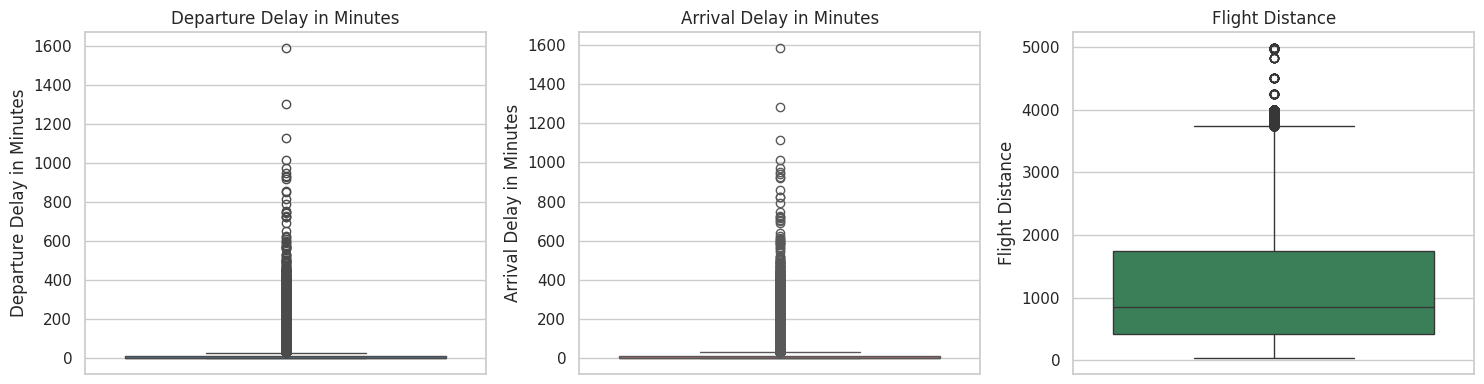

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df_raw["Departure Delay in Minutes"], ax=axes[0], color="steelblue")
axes[0].set_title("Departure Delay in Minutes")

sns.boxplot(y=df_raw["Arrival Delay in Minutes"], ax=axes[1], color="indianred")
axes[1].set_title("Arrival Delay in Minutes")

sns.boxplot(y=df_raw["Flight Distance"], ax=axes[2], color="seagreen")
axes[2].set_title("Flight Distance")

plt.tight_layout()
plt.show()

**Interpretation:** by the IQR rule, a large fraction of both delay columns are flagged as
"outliers" — this is expected and characteristic of delay data in general, not a defect of this
particular dataset. Because more than half of all flights depart and arrive exactly on time (delay =
0, as shown in Part 11), the interquartile range itself is very narrow (often `Q1 = Q3 = 0` for
on-time-heavy columns), so almost *any* positive delay technically falls outside a 1.5×IQR fence built
from a distribution with that much mass at zero. Mechanically applying the IQR rule and deleting every
flagged row here would be a serious mistake: it would remove the majority of flights that experienced
*any* delay at all, destroying exactly the signal the model needs to learn, and would bias the
remaining dataset toward only on-time flights. **Decision: no rows are removed based on this IQR
screen.** `Flight Distance` and `Age` show a much smaller and more typical proportion of flagged
points, consistent with genuine, unremarkable variation in trip length and passenger age rather than
any data problem.

## 10. Data Cleaning

Based on the audit in Section 9, exactly one cleaning action is justified: removing the rows where the
target is missing. Nothing else in the dataset requires modification.

In [18]:
df = df_raw.dropna(subset=["Arrival Delay in Minutes"]).reset_index(drop=True)

print(f"Rows before cleaning: {df_raw.shape[0]:,}")
print(f"Rows after cleaning:  {df.shape[0]:,}")
print(f"Rows removed:         {df_raw.shape[0] - df.shape[0]:,} "
      f"({100 * (df_raw.shape[0] - df.shape[0]) / df_raw.shape[0]:.2f}% of the original data)")

assert df.isnull().sum().sum() == 0, "Unexpected missing values remain after cleaning."
print("\nNo missing values remain in the cleaned dataset.")

Rows before cleaning: 129,880
Rows after cleaning:  129,487
Rows removed:         393 (0.30% of the original data)

No missing values remain in the cleaned dataset.


From this point forward, `df` (not `df_raw`) is the dataset used throughout the rest of the notebook.
Keeping `df_raw` unmodified above is a deliberate habit: it allows any step in the audit to be
re-verified against the original file at any time.

## 11. Exploratory Data Analysis

Every plot in this section is chosen to answer a specific question relevant to building a regression
model — not included simply because it is possible to draw. With almost 130,000 rows, we also have to
be deliberate about *how* we plot: a raw scatterplot of 100,000+ overlapping points is unreadable and
slow to render, so where relevant we use 2D density plots or a fixed random subsample purely for
visualization (never for modeling).

### 11.1 Target distribution

**Question:** what does the distribution of `Arrival Delay in Minutes` look like, and does it suggest
any transformation should be considered?

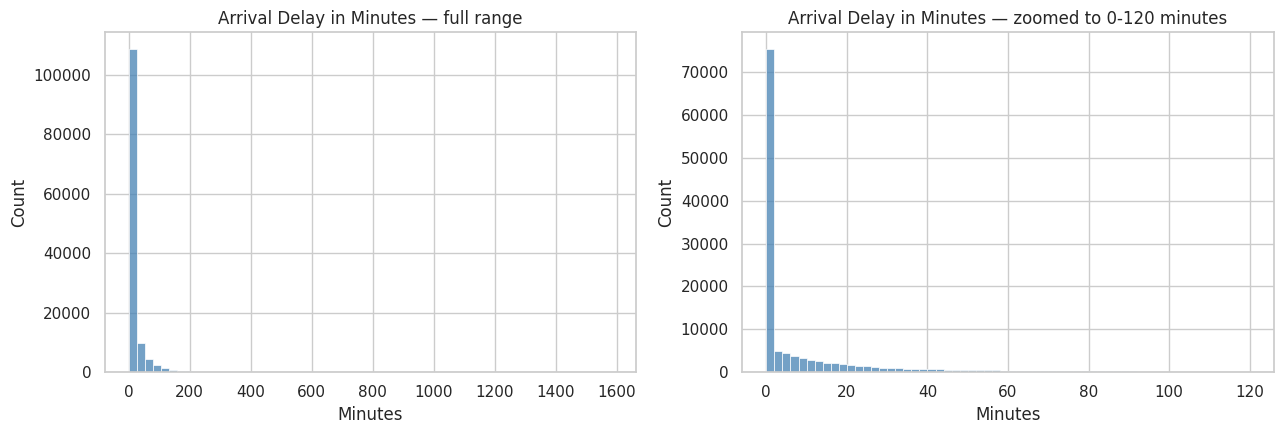

count    129487.000000
mean         15.091129
std          38.465650
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

Skewness: 6.67
Percentage of flights with zero arrival delay: 56.2%


In [19]:
target = "Arrival Delay in Minutes"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[target], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Arrival Delay in Minutes — full range")
axes[0].set_xlabel("Minutes")

sns.histplot(df[df[target] <= 120][target], bins=60, ax=axes[1], color="steelblue")
axes[1].set_title("Arrival Delay in Minutes — zoomed to 0-120 minutes")
axes[1].set_xlabel("Minutes")

plt.tight_layout()
plt.show()

print(df[target].describe())
print(f"\nSkewness: {df[target].skew():.2f}")
print(f"Percentage of flights with zero arrival delay: {100 * (df[target] == 0).mean():.1f}%")

**Interpretation:**

- **Center:** the median delay is close to 0 minutes, and roughly 56% of flights arrive with *exactly*
  zero recorded delay.
- **Spread:** the bulk of delayed flights fall within roughly 0–60 minutes, but the column has a very
  long right tail extending past 1,500 minutes.
- **Skewness:** a skewness coefficient of about 6.7 indicates **strong positive (right) skew** — this
  matches the earlier observation in Section 7.2 that the mean sits well above the median.
- **Outliers:** the extreme tail is made up of genuinely delayed flights, not data errors (Section
  9.5) — we do not remove them.
- **Transformation consideration:** a common response to a right-skewed target is a log transform
  (e.g., `log1p(delay)`). We deliberately **do not apply one** here, for a reason worth stating
  explicitly: this target has a very large spike of exact zeros (56% of rows), and delay in raw
  minutes is the unit the business actually needs a prediction in — a log-transformed prediction would
  need to be exponentiated back before it is useful, and doing so introduces a systematic bias
  correction problem (Jensen's inequality) which is a subtlety often skipped incorrectly. This
  notebook keeps the target in its natural, interpretable units and instead relies on evaluating the
  model honestly against this skew (Parts 22–24) rather than hiding it with a transform. This
  trade-off is revisited explicitly in Part 40 and offered as an independent exercise in the practical
  challenges section.

### 11.2 Numerical feature distributions

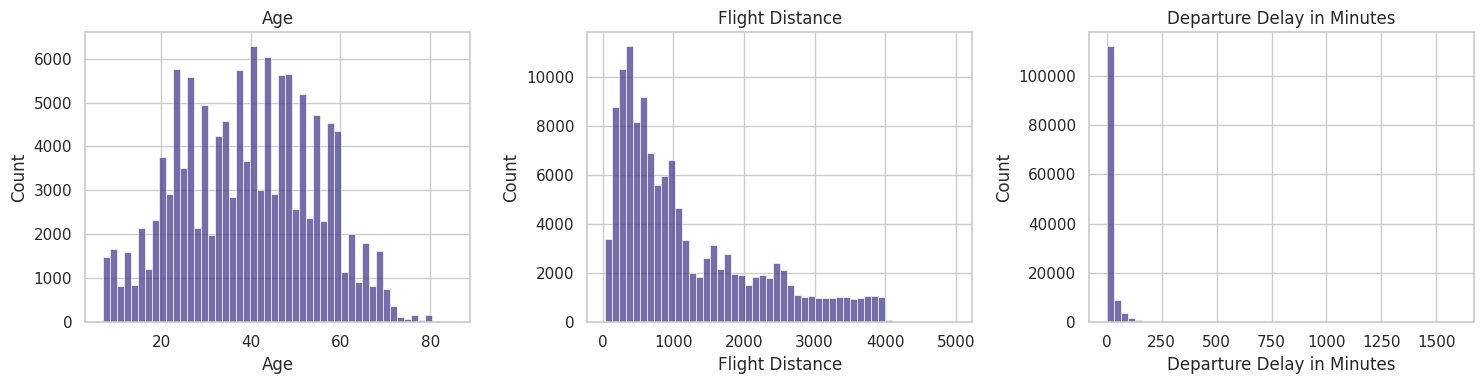

In [20]:
numeric_features_for_hist = ["Age", "Flight Distance", "Departure Delay in Minutes"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_features_for_hist):
    sns.histplot(df[col], bins=50, ax=ax, color="darkslateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Age` is roughly bell-shaped with a slight concentration in the 25–45 range, consistent with a typical
air-travel population. `Flight Distance` is right-skewed with several common route-length clusters
rather than a smooth curve — reflecting that airlines fly a finite set of specific routes rather than
a continuum of distances. `Departure Delay in Minutes` shows the same heavy right skew and zero-spike
already discussed for the target, which is expected since the two columns describe the same
underlying phenomenon at two points in a flight's timeline.

### 11.3 Boxplots for the ordinal service ratings

/tmp/ipykernel_87/2489038959.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


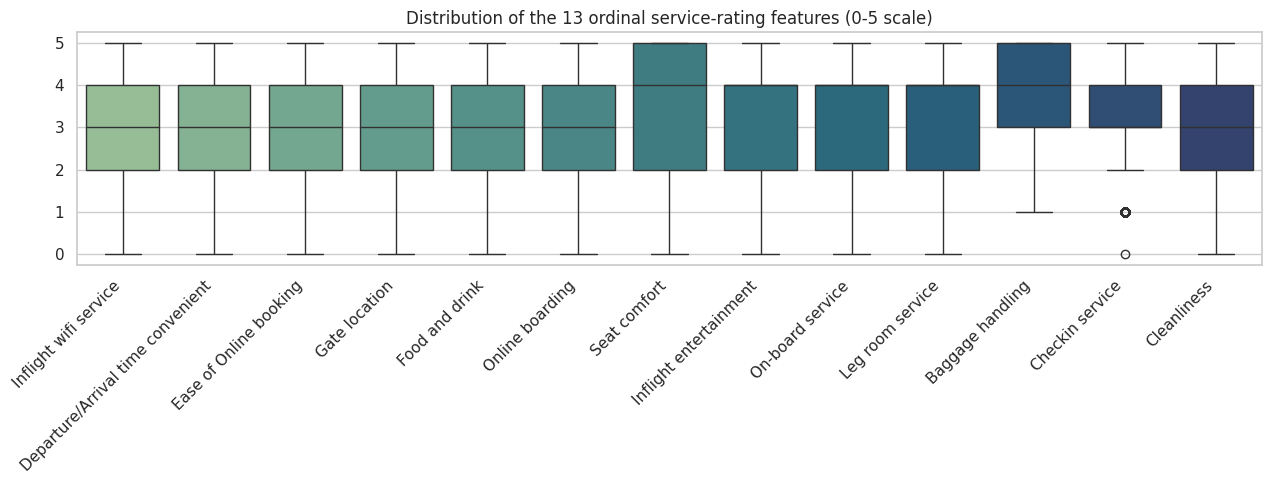

In [21]:
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Cleanliness",
]

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df[rating_cols], ax=ax, palette="crest")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Distribution of the 13 ordinal service-rating features (0-5 scale)")
plt.tight_layout()
plt.show()

All thirteen ratings occupy the same 0–5 scale, with medians mostly in the 3–4 range and interquartile
ranges of similar width — none of them show a degenerate, single-value distribution (already
confirmed numerically in Section 9.4). This plot is primarily a sanity check confirming the ratings
behave as expected before we look at how they relate to the target next.

### 11.4 Correlation matrix

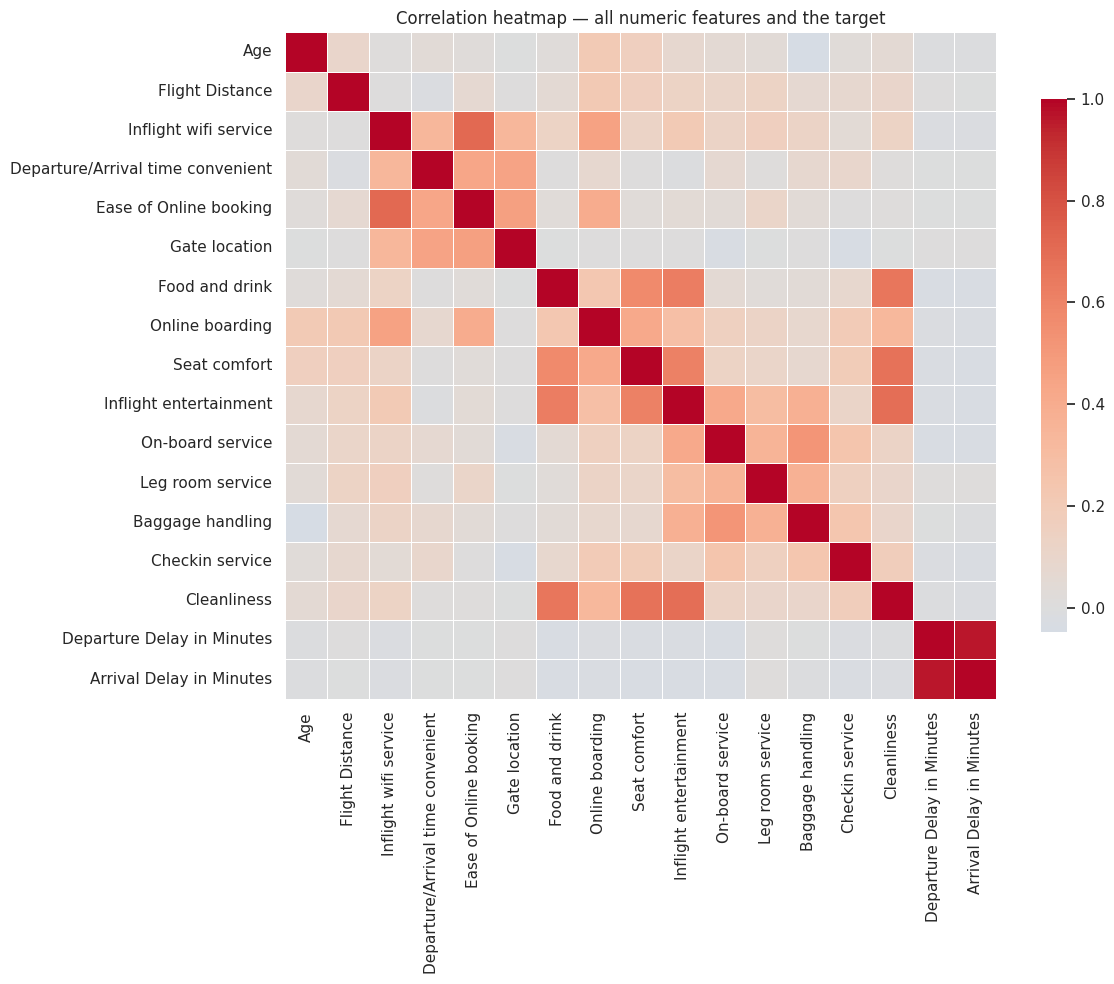

In [22]:
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, cmap="coolwarm", center=0, annot=False,
    linewidths=0.4, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Correlation heatmap — all numeric features and the target")
plt.tight_layout()
plt.show()

In [23]:
target_corr = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)
target_corr.to_frame(name="correlation_with_target")

,correlation_with_target
Departure Delay in Minutes,0.965291
On-board service,-0.034789
Food and drink,-0.031715
Seat comfort,-0.030521
Inflight entertainment,-0.030230
Online boarding,-0.022730
Checkin service,-0.021705
Inflight wifi service,-0.017749
Cleanliness,-0.016546
Leg room service,0.011346


**Interpretation:**

- **`Departure Delay in Minutes`** correlates with the target at approximately **0.965** — an
  extremely strong **positive** linear relationship: the more delayed a flight is at departure, the
  more delayed it tends to be at arrival. This is the dominant signal in the entire dataset.
- Every other numeric feature — `Age`, `Flight Distance`, and all thirteen service ratings —
  correlates with `Arrival Delay in Minutes` at a magnitude below **0.04**, i.e., essentially
  **near-zero correlation**. This makes sense: how comfortable a seat is, or how far a flight travels,
  has no obvious causal reason to be linearly related to how many minutes late it lands.
- A cluster of moderate **positive correlations among several service ratings themselves** is visible
  in the heatmap (e.g., `Inflight entertainment` with `Cleanliness` and `Food and drink`) — passengers
  who rate one aspect of the experience highly tend to rate others highly too. This is examined
  properly as a multicollinearity question in Part 14, since correlation among *features* is a
  different concern from correlation between a feature and the target.
- **Reminder:** correlation measures the strength of a *linear, pairwise* association. It does not
  imply causation, and it does not rule out a genuine but *non-linear* relationship between a
  near-zero-correlation feature and the target (checked with scatterplots below).

### 11.5 Feature vs. target relationships

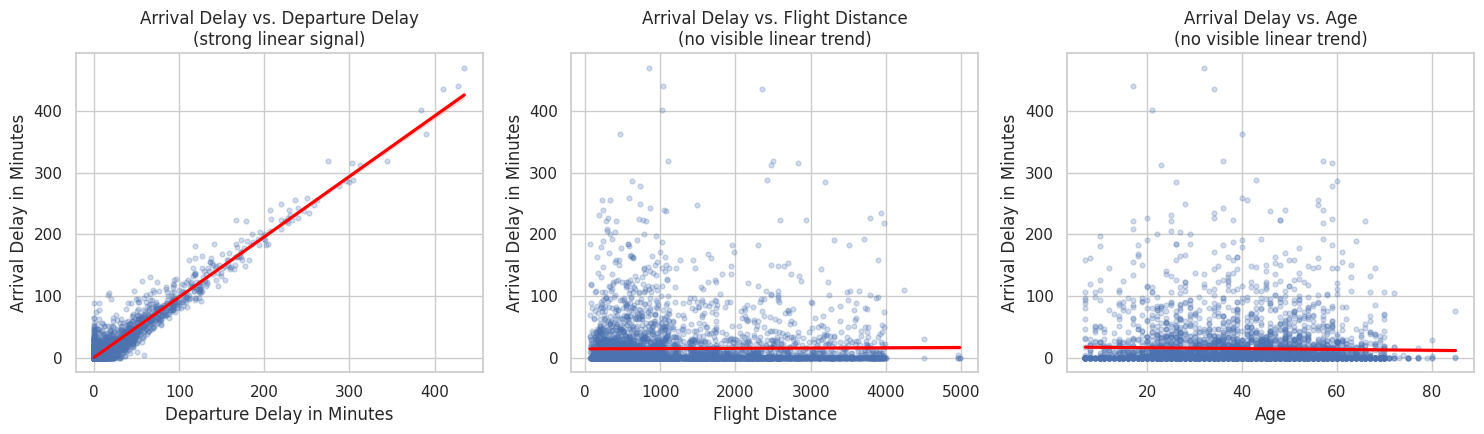

In [24]:
plot_sample = df.sample(n=5000, random_state=RANDOM_STATE)  # sampling only for visual clarity

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.regplot(
    data=plot_sample, x="Departure Delay in Minutes", y=target,
    ax=axes[0], scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"},
)
axes[0].set_title("Arrival Delay vs. Departure Delay\n(strong linear signal)")

sns.regplot(
    data=plot_sample, x="Flight Distance", y=target,
    ax=axes[1], scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"},
)
axes[1].set_title("Arrival Delay vs. Flight Distance\n(no visible linear trend)")

sns.regplot(
    data=plot_sample, x="Age", y=target,
    ax=axes[2], scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"},
)
axes[2].set_title("Arrival Delay vs. Age\n(no visible linear trend)")

plt.tight_layout()
plt.show()

The scatterplot against `Departure Delay in Minutes` shows a tight, clearly linear band around the
fitted regression line — visually confirming the ~0.965 correlation and supporting the linearity
assumption (Section 5.1) for this specific relationship. The plots against `Flight Distance` and
`Age` show a wide, formless cloud of points with an essentially flat fitted line: there is no
apparent linear (or obvious non-linear) relationship between either feature and arrival delay. This
does not mean these features are useless to include — a multiple regression model can still combine
many weak signals — but it does set a realistic expectation that most of the model's explanatory power
will come from one feature.

### 11.6 Categorical features vs. target

/tmp/ipykernel_87/3031100581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=ax, showfliers=False, palette="Set2")
/tmp/ipykernel_87/3031100581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=ax, showfliers=False, palette="Set2")


/tmp/ipykernel_87/3031100581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=ax, showfliers=False, palette="Set2")
/tmp/ipykernel_87/3031100581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=ax, showfliers=False, palette="Set2")


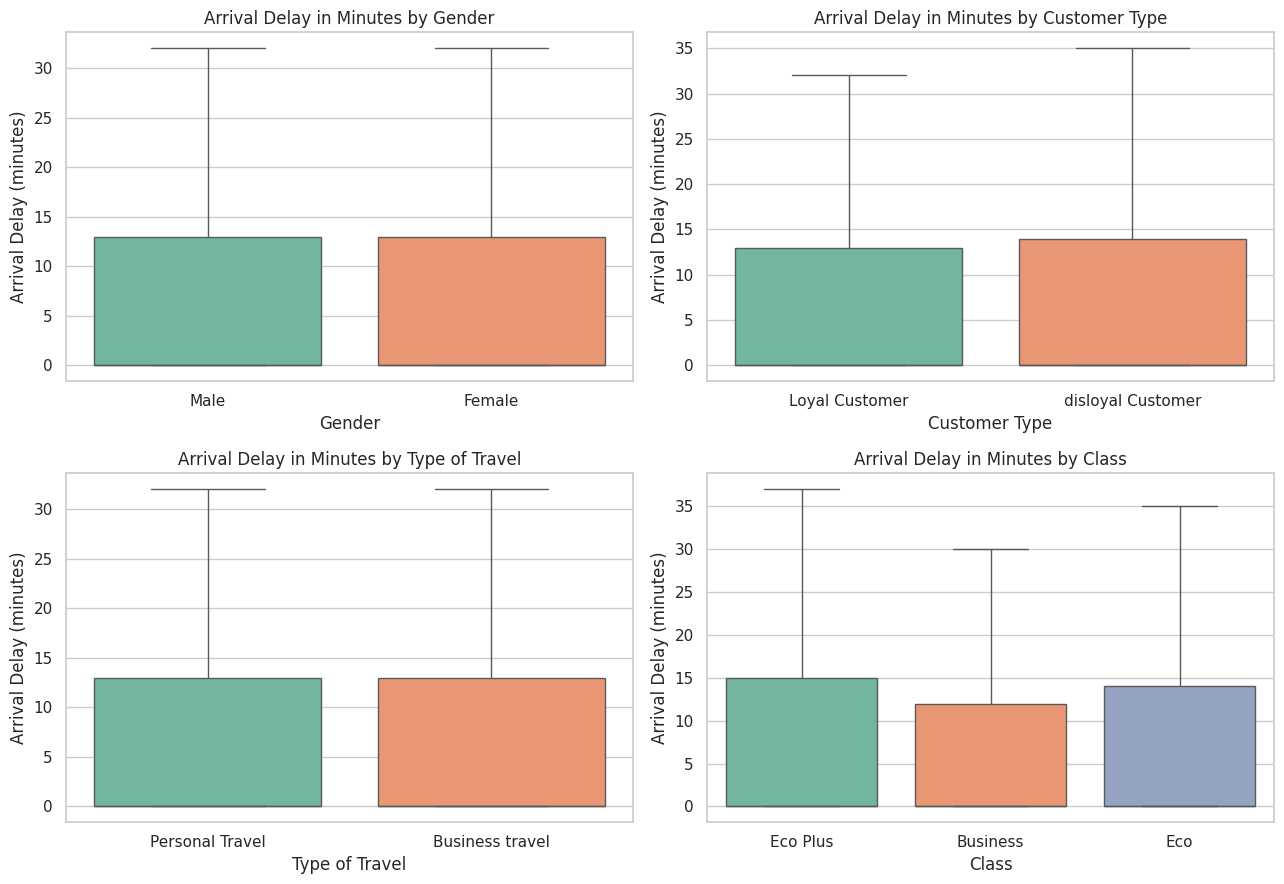

In [25]:
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    sns.boxplot(data=df, x=col, y=target, ax=ax, showfliers=False, palette="Set2")
    ax.set_title(f"{target} by {col}")
    ax.set_ylabel("Arrival Delay (minutes)")

plt.tight_layout()
plt.show()

(Extreme outliers are hidden in this plot with `showfliers=False` purely so the boxes themselves stay
readable — they have not been removed from the data.) The median and interquartile range of arrival
delay look broadly similar across `Gender`, `Customer Type`, `Type of Travel`, and `Class`. None of
these categorical variables show an obviously different typical delay across groups; whatever small
differences exist are far smaller than the effect of `Departure Delay in Minutes` observed above. This
is a realistic and informative finding: it tells us not to expect these categorical variables to
carry much weight in the final linear model, without pre-judging the outcome before the model is
actually fit.

### 11.7 Statistical summary — mean, variance, and correlation vs. covariance

For completeness, and because these definitions are easy to blur together:

- **Covariance** measures the direction of the joint variation between two variables, but its
  magnitude depends on the units of both variables, which makes it hard to compare across variable
  pairs (e.g., covariance between `Flight Distance` in kilometers and delay in minutes is not
  comparable to covariance between `Age` in years and delay in minutes).
- **Correlation** (specifically, the **Pearson correlation coefficient** used throughout this
  notebook) is covariance standardized by the two variables' standard deviations, which rescales the
  result to always fall between $-1$ and $+1$, making it comparable across any pair of variables:

$$r_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \, \sigma_Y}$$

- **When Pearson correlation can mislead:** it only captures **linear** association. Two variables
  can have a strong, obvious *non-linear* relationship (e.g., a U-shape) and still show a Pearson
  correlation near zero, because the positive and negative parts of the curved relationship cancel
  out in the linear summary. This is exactly why the scatterplots in Section 11.5 are examined
  visually rather than relying on the correlation table alone.

In [26]:
summary_stats = df[["Age", "Flight Distance", "Departure Delay in Minutes", target]].agg(
    ["mean", "median", "var", "std"]
).T
summary_stats

,mean,median,var,std
Age,39.428761,40.0,228.541731,15.117597
Flight Distance,1190.210662,844.0,995127.857371,997.560954
Departure Delay in Minutes,14.643385,0.0,1438.902365,37.932867
Arrival Delay in Minutes,15.091129,0.0,1479.606248,38.465650


## 12. Feature Engineering

"Feature engineering" for this dataset is largely a *selection and justification* exercise rather
than a heavy transformation exercise, and it is worth being upfront about that rather than inventing
engineered features the data does not call for.

### 12.1 Candidate features

| Category | Columns |
|---|---|
| Strong linear signal | `Departure Delay in Minutes` (r ≈ 0.965) |
| Weak but plausibly informative | `Age`, `Flight Distance`, 13 service ratings (\|r\| < 0.04 individually, but may combine with categorical context) |
| Categorical context | `Gender`, `Customer Type`, `Type of Travel`, `Class` |
| Identifier columns | None present |
| Excluded (leakage / wrong task) | `satisfaction` (Section 8.4) |

### 12.2 Why we do not select features by correlation with the target alone

It would be tempting, after Section 11.4, to keep only `Departure Delay in Minutes` and drop every
feature with near-zero correlation. This notebook deliberately does **not** do that, for several
reasons that generalize well beyond this dataset:

1. **Domain meaning:** cabin class, travel purpose, and demographics are operationally meaningful to
   an airline even if their marginal linear correlation with delay is small; a production model is
   often expected to at least *consider* known operational context.
2. **Multicollinearity is a property of the full model, not of pairwise correlations** — a feature
   with near-zero correlation with the target can still occasionally combine with others in ways a
   simple pairwise check would miss (though Part 14's VIF analysis confirms this is not a significant
   concern here).
3. **Validation performance, not raw correlation, is the real test.** The right way to determine
   whether the weak features are worth keeping is to compare model performance with and against them
   using proper train/test evaluation and cross-validation — which is exactly what the regularization
   experiments in Parts 26–27 do. Lasso, in particular, is used later specifically because it can
   perform data-driven feature selection by shrinking uninformative coefficients toward zero,
   rather than us guessing which features to discard by eye beforehand.
4. **No leakage variables need to be engineered away** beyond the `satisfaction` decision already
   made in Section 8.4 — there is no column here that encodes post-outcome information about arrival
   delay itself.

**Decision:** all remaining columns (4 categorical + 16 numerical, `satisfaction` and the target
excluded) are carried forward as candidate features into the modeling pipeline. No new columns are
engineered for the baseline linear model — a decision that is itself revisited in Part 42's
discussion of polynomial features, and offered as an independent exercise (Challenge 1).

In [27]:
FEATURE_COLUMNS = [c for c in df.columns if c not in ("satisfaction", target)]
CATEGORICAL_FEATURES = df[FEATURE_COLUMNS].select_dtypes(include=["object", "string"]).columns.tolist()
NUMERICAL_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

print(f"Total candidate features: {len(FEATURE_COLUMNS)}")
print(f"  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  Numerical   ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")

Total candidate features: 20
  Categorical (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']
  Numerical   (16): ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes']


## 13. Train/Test Split

### 13.1 Why we split before doing anything else model-related

The **training set** is used to fit the model (and, later, to run cross-validation for tuning). The
**test set** is held back and touched only once, at the very end (Part 29), to report a final,
honest estimate of how the model performs on data it has never influenced in any way — not during
imputation, not during scaling, not during feature selection, and not during hyperparameter tuning.

If information from the test set leaks into any of those earlier steps — for example, by computing a
scaler's mean and standard deviation on the *full* dataset before splitting — the test score will be
**optimistically biased**: it will look better than the model's true ability to generalize, because
the "unseen" data was not actually unseen by the preprocessing statistics. This is one of the most
common and most damaging mistakes in applied machine learning, and it is treated as a hard rule
throughout the rest of this notebook: **every statistic used for preprocessing is learned from the
training data only**, via a `Pipeline` (Part 16) that guarantees this automatically, including inside
cross-validation folds.

### 13.2 Is a random split appropriate here?

The dataset has **no date, time, or flight-sequence column** — there is no way to determine which
row happened "before" another. A **time-aware split** (training on earlier data, testing on later
data) is the correct choice whenever such a temporal ordering exists and matters — for example, if we
were worried about *concept drift* (delay patterns changing season to season) or wanted to simulate
genuinely forecasting the future from the past. Since this dataset offers no way to order observations
in time, and there is no reason from the data dictionary to believe rows are secretly time-ordered, a
**random split is the appropriate and standard choice** here. This distinction is worth remembering
for future projects: always check for a temporal structure before defaulting to a random split.

In [28]:
X = df[FEATURE_COLUMNS]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} rows ({100 * len(X_train) / len(X):.0f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows ({100 * len(X_test) / len(X):.0f}%)")
print()
print("Training target summary:")
print(y_train.describe())
print()
print("Test target summary:")
print(y_test.describe())

Training set: 103,589 rows (80%)
Test set:     25,898 rows (20%)

Training target summary:
count    103589.000000
mean         14.963239
std          37.695096
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1011.000000
Name: Arrival Delay in Minutes, dtype: float64

Test target summary:
count    25898.000000
mean        15.602672
std         41.401453
min          0.000000
25%          0.000000
50%          0.000000
75%         13.000000
max       1584.000000
Name: Arrival Delay in Minutes, dtype: float64


The training and test targets show very similar distributions (comparable means, medians, and
spread), which is expected from a random split of a large dataset and gives some initial confidence
that the test set is a fair, representative sample for the final evaluation in Part 29.

## 14. Baseline Model

### 14.1 Why a baseline comes before the "real" model

A baseline answers a deceptively important question: *how good is a prediction that uses no
learning at all?* Every subsequent model in this notebook must be judged **relative to this
baseline**, not in isolation. An R² or RMSE number means very little on its own — "RMSE = 10 minutes"
sounds mediocre until you learn that guessing the average delay for every flight gives an RMSE of over
40 minutes, at which point 10 minutes looks like a substantial improvement.

The standard baseline for regression is a **mean-prediction ("dummy") model**: predict the training
set's mean target value for every single test observation, regardless of its features.

In [29]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = mean_squared_error(y_test, baseline_predictions) ** 0.5
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline (mean-prediction) performance on the TEST set:")
print(f"  MAE : {baseline_mae:.2f} minutes")
print(f"  RMSE: {baseline_rmse:.2f} minutes")
print(f"  R^2 : {baseline_r2:.4f}")

Baseline (mean-prediction) performance on the TEST set:
  MAE : 20.78 minutes
  RMSE: 41.41 minutes
  R^2 : -0.0002


**Interpretation:** the baseline's R² is essentially **zero**, by construction — a model that always
predicts the same constant explains none of the variance in the target. Its RMSE of roughly 41
minutes represents the typical error you would incur with no model at all, simply guessing the
overall average delay every time. This is the number every model built from here onward has to beat
meaningfully, not just marginally, to be considered worth its added complexity.

## 15. Preprocessing Pipeline

### 15.1 What needs preprocessing here, and what does not

Being precise about this avoids two opposite mistakes: preprocessing that is not needed (wasted
complexity, and in some cases actively harmful — see Part 21), and skipping preprocessing that is
genuinely required (the model will simply fail to fit, in the case of categorical text columns).

| Requirement | Needed here? | Why |
|---|---|---|
| Missing-value imputation | Not strictly needed for the features (no feature has missing values, Section 9.1) — included anyway as a defensive default | Production pipelines should not silently break if a new batch of data contains an unexpected missing value |
| Feature scaling for `LinearRegression` | Not required for correct predictions (Part 21 demonstrates this directly) | Ordinary least squares is scale-invariant in terms of the *predictions* and R² it produces |
| Feature scaling for `Ridge` / `Lasso` / `ElasticNet` | **Required** | These add a penalty on the *size* of coefficients, and that penalty is only fair across features if they are on comparable scales (Part 25) |
| One-hot encoding for categoricals | **Required** | `LinearRegression` and friends require purely numeric input; text categories must be converted |

We build **one preprocessing pipeline that includes scaling**, and use it consistently for every
model in this notebook (including plain `LinearRegression`). This is both simpler to maintain than
having two separate pipelines, and correct: scaling does not change plain OLS predictions or R²
(demonstrated explicitly in Part 21), so there is no accuracy cost to scaling, only a
consistency benefit.

### 15.2 Building the pipeline with `ColumnTransformer`

In [30]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, NUMERICAL_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

**Explaining every component:**

- **`SimpleImputer(strategy="median")` for numerical features:** the median is preferred over the
  mean as a defensive default because it is robust to the extreme right-skew already documented in
  Section 11.1/11.2 — an outlier-heavy column's mean can be pulled far from the "typical" value, while
  the median is not. This dataset does not currently need this step to fire (no missing numeric
  values), but including it protects the pipeline against new data in production that does contain
  gaps, without having to remember to add it later.
- **`StandardScaler()` for numerical features:** rescales each numeric feature to have mean 0 and
  standard deviation 1, learned **only from the training fold** each time the pipeline is fit. This
  is required for the regularized models (Part 25) and is harmless for plain OLS.
- **`SimpleImputer(strategy="most_frequent")` for categorical features:** fills any missing category
  with the most common category, again as a defensive default.
- **`OneHotEncoder(drop="first", handle_unknown="ignore")` for categorical features:** converts each
  category into a set of binary (0/1) columns. `drop="first"` removes one category per feature (the
  "reference" category) to avoid the **dummy variable trap** — perfect multicollinearity that would
  otherwise exist between the one-hot columns and the intercept (if all categories were kept, they
  would always sum to exactly 1, which is a linear combination of the intercept term). `handle_unknown
  ="ignore"` ensures that if a brand-new, previously unseen category appears in future production data
  (or, mechanically, in a test fold during cross-validation), the pipeline encodes it as all zeros
  rather than crashing.
- **`ColumnTransformer`:** applies the numerical pipeline to the numeric columns and the categorical
  pipeline to the categorical columns, then concatenates the results into a single feature matrix,
  keeping the two kinds of preprocessing cleanly separated and independently testable.

### 15.3 Why this must be a `Pipeline`, not manual preprocessing

If we instead called `.fit_transform()` on a scaler or encoder using the **entire** `X` before
splitting (or even using all of `X_train` once, and reusing those exact fitted statistics inside every
cross-validation fold without refitting), we would leak information about the validation/test rows
into the transformation. Wrapping everything in a single `Pipeline` guarantees that every time the
pipeline is fit — including automatically, once per fold, inside `cross_validate` and `GridSearchCV`
later in this notebook — the imputer, scaler, and encoder are refit from scratch using **only** the
data available in that particular training fold. This is not a stylistic preference; it is the
difference between a valid and an invalid evaluation.

## 16. Linear Regression

### 16.1 Fitting the model

We now combine the preprocessing pipeline with `LinearRegression()` into a single end-to-end
pipeline, and fit it on the training data only.

In [31]:
linear_regression_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression()),
])

linear_regression_pipeline.fit(X_train, y_train)

print("Linear Regression pipeline fitted successfully.")

Linear Regression pipeline fitted successfully.


**What just happened, mechanically:**

1. The `ColumnTransformer` learned the median/most-frequent values, the `StandardScaler`'s mean and
   standard deviation, and the `OneHotEncoder`'s category list — all from `X_train` only.
2. `X_train` was transformed into a fully numeric matrix.
3. `LinearRegression()` solved the OLS closed-form equation from Section 4.6 on that transformed
   matrix to find the coefficients that minimize the sum of squared residuals on the training data.

### 16.2 Retrieving the coefficients correctly

Because the pipeline includes one-hot encoding, the number of transformed feature columns is **not**
the same as the number of original columns — one-hot encoding of `Class` (3 categories, one dropped)
produces 2 columns, for example. Mapping coefficients back to human-readable names requires asking the
fitted `ColumnTransformer` for its actual output feature names, rather than assuming an order.

In [32]:
feature_names_out = linear_regression_pipeline.named_steps["preprocessing"].get_feature_names_out()
coefficients = linear_regression_pipeline.named_steps["model"].coef_
intercept = linear_regression_pipeline.named_steps["model"].intercept_

coef_table = pd.DataFrame({
    "feature": feature_names_out,
    "coefficient": coefficients,
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

print(f"Intercept: {intercept:.4f}")
print(f"\nNumber of transformed features: {len(feature_names_out)}")
coef_table

Intercept: 14.9748

Number of transformed features: 21


,feature,coefficient
0,numerical__Departure Delay in Minutes,36.312706
1,categorical__Class_Eco Plus,0.489577
2,categorical__Type of Travel_Personal Travel,-0.375547
3,categorical__Class_Eco,0.372381
4,categorical__Customer Type_disloyal Customer,-0.270182
5,numerical__Food and drink,-0.155939
6,numerical__On-board service,-0.151736
7,categorical__Gender_Male,-0.098768
8,numerical__Cleanliness,0.087852
9,numerical__Flight Distance,-0.063298


**Reading the coefficient table:** because every numerical feature was standardized before fitting,
these coefficients are directly comparable to one another as "effect per one standard deviation of the
feature," which is what allows `Departure Delay in Minutes` to visibly and correctly dominate this
table — consistent with everything found in the EDA. The one-hot encoded categorical coefficients
(e.g., `categorical__Class_Eco`) represent the estimated difference in arrival delay relative to the
**dropped reference category** for that feature (here, `Business` class, since `drop="first"` removes
the alphabetically-first category), holding all other features constant. This interpretation is
revisited more carefully, with the actual reference categories named explicitly, in Part 20.

## 17. Model Evaluation

We evaluate on the held-out test set using several complementary metrics — no single metric tells the
whole story, which is why the notebook reports all of them together and interprets them jointly rather
than in isolation.

In [33]:
def regression_report(y_true, y_pred, n_features, label=""):
    '''Compute a standard set of regression metrics, including adjusted R^2.'''
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return pd.Series(
        {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "Adjusted_R2": adj_r2},
        name=label,
    )

linreg_predictions = linear_regression_pipeline.predict(X_test)

linreg_report = regression_report(
    y_test, linreg_predictions, n_features=len(feature_names_out), label="Linear Regression (test set)"
)
linreg_report.to_frame().T

,MAE,MSE,RMSE,R2,Adjusted_R2
Linear Regression (test set),5.336397,99.631185,9.981542,0.941873,0.941825


**MAE (Mean Absolute Error)** — the average absolute size of the model's error, in the target's
original units (minutes). It is directly interpretable: *"on average, our arrival-delay prediction is
off by about this many minutes."* Because it uses absolute values rather than squares, it treats a
20-minute error and two 10-minute errors as contributing the same total, and is comparatively
insensitive to a small number of extreme errors.

**MSE (Mean Squared Error)** — the same quantity being minimized during training (Section 4.5), now
used as an evaluation metric. Its units are *minutes²*, which is not directly interpretable on its own
— it exists mainly to be square-rooted into RMSE.

**RMSE (Root Mean Squared Error)** — the square root of MSE, which brings the units back to minutes,
making it directly comparable to MAE. RMSE is generally easier to interpret than MSE for exactly this
reason (matching units with the target), while still retaining MSE's property of penalizing large
errors more heavily than small ones. Whenever RMSE is noticeably larger than MAE (as it typically is
here), that gap itself is informative: it signals that a subset of predictions have unusually large
errors pulling the squared-error metric upward, which the error-analysis in Part 27 investigates
directly.

**R² (Coefficient of Determination)** — the proportion of variance in the target that the model
explains, relative to always predicting the mean (the baseline from Part 14):

$$R^2 = 1 - \frac{\text{Residual Sum of Squares}}{\text{Total Sum of Squares}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

**What R² does *not* mean:** it does not mean "percentage of predictions that are correct," it does
not by itself prove the model is well-specified (a model can have a high R² and still badly violate
regression assumptions, or be badly wrong for a specific subgroup — Part 27 and Part 33 return to
this), and it can be pushed higher simply by adding more features even when those features are not
truly useful, which is exactly the distortion **Adjusted R²** is designed to correct for.

**Adjusted R²** penalizes R² for the number of predictors used, $p$, relative to the number of
observations, $n$:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$

This is most useful for **comparing models with different numbers of features** — plain R² can never
decrease when a feature is added, even a useless one, while adjusted R² can decrease if the added
feature does not improve the fit enough to justify the extra parameter. It is one useful piece of
evidence among several (Part 28), not a sufficient criterion on its own.

## 18. Residual Analysis

### 18.1 Actual vs. Predicted

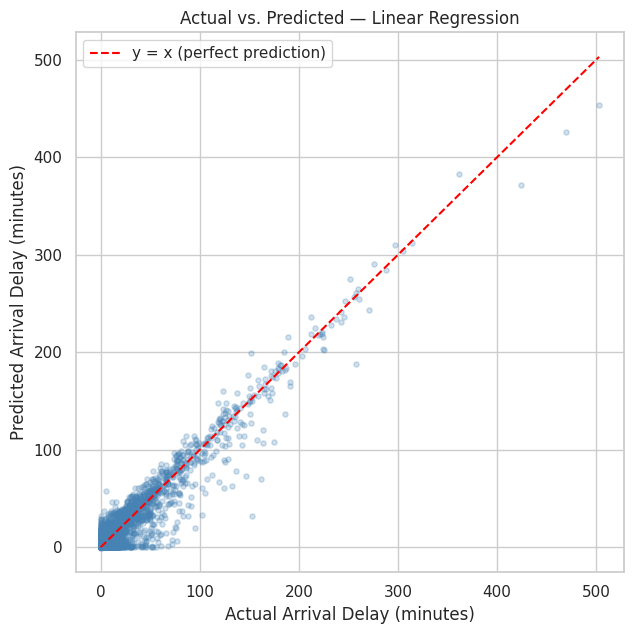

In [34]:
plot_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=5000, replace=False)
y_test_sample = y_test.iloc[plot_idx]
pred_sample = linreg_predictions[plot_idx]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test_sample, pred_sample, alpha=0.25, s=14, color="steelblue")

lims = [0, max(y_test_sample.max(), pred_sample.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="y = x (perfect prediction)")

ax.set_xlabel("Actual Arrival Delay (minutes)")
ax.set_ylabel("Predicted Arrival Delay (minutes)")
ax.set_title("Actual vs. Predicted — Linear Regression")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** the bulk of points cluster tightly around the red $y = x$ reference line,
confirming visually what the R² already suggested — the model tracks actual delay closely across most
of its range. Points **above** the line are **underpredictions** (the model guessed lower than what
actually happened); points **below** the line are **overpredictions**. Some spread widens visibly for
larger actual delays, and a small number of points, mostly at large delay values, sit noticeably off
the line — the model is systematically less precise for the most extreme delays than for typical ones.
This is examined formally as heteroscedasticity in Section 18.3, and is investigated case-by-case as
part of the error analysis in Part 27.

### 18.2 Residual vs. Predicted plot

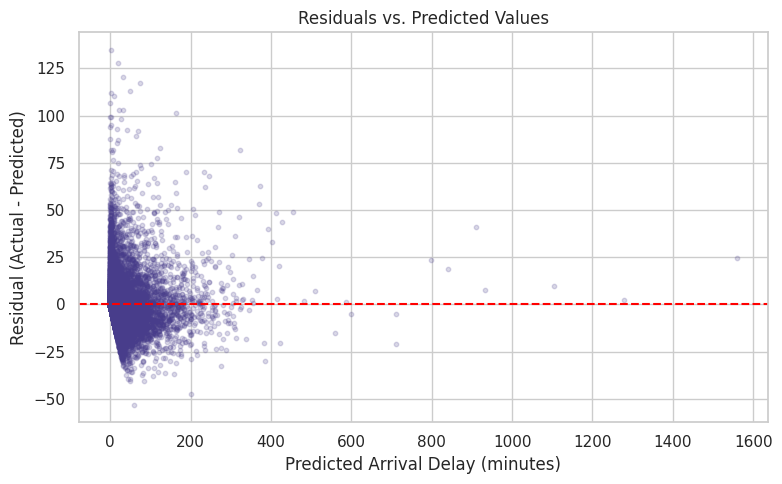

In [35]:
residuals = y_test.values - linreg_predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(linreg_predictions, residuals, alpha=0.2, s=10, color="darkslateblue")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted Arrival Delay (minutes)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residuals vs. Predicted Values")
plt.tight_layout()
plt.show()

**What this plot is checking:** if the model were correctly specified and homoscedastic, residuals
should form a structureless, roughly constant-width horizontal band centered on zero across the entire
range of predicted values (Sections 5.1 and 5.3). What we actually observe is a band that **widens
noticeably as predicted delay increases** — a classic **funnel shape** — meaning the model's errors are
small and tight for flights predicted to have low delay, and considerably larger and more variable for
flights predicted to have high delay. This is direct visual evidence of **heteroscedasticity**,
confirmed with a formal test in Section 18.4. We do **not** conclude "the model is bad" purely from
this shape — the point predictions themselves remain unbiased (Section 5.3) — but this is genuine,
visible evidence that should temper any claim of a uniformly reliable prediction interval across the
whole range of the target.

### 18.3 Residual distribution and Q-Q plot

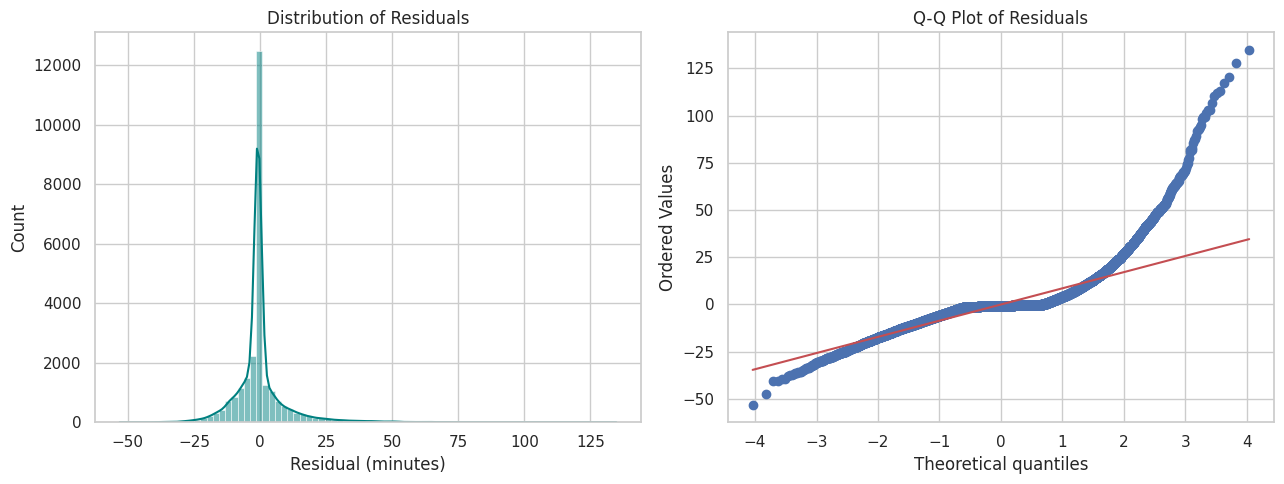

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(residuals, bins=80, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Residuals")
axes[0].set_xlabel("Residual (minutes)")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

**What a Q-Q plot checks:** it compares the quantiles of the observed residuals against the quantiles
that would be expected if the residuals were perfectly normally distributed. Points falling on the
diagonal reference line indicate agreement with normality; systematic curvature away from the line
indicates a departure from it.

**What we see:** the residual histogram is heavily concentrated near zero but has long tails in both
directions, and the Q-Q plot shows clear curvature away from the diagonal at both ends — the residuals
have **heavier tails than a normal distribution** (more extreme positive and negative residuals than a
Gaussian would produce). This is consistent with, and largely a direct consequence of, the target's
own heavy right skew documented in Section 11.1. As discussed in Section 5.4, this primarily affects
the validity of classical small-sample inference (confidence intervals and p-values on coefficients),
not the validity of the point predictions themselves, and its practical impact is further reduced by
the very large sample size in this dataset (the Central Limit Theorem applies to the sampling
distribution of the coefficients even when individual residuals are not normal). We verify this claim
statistically, rather than only visually, next.

### 18.4 Residual vs. an important feature

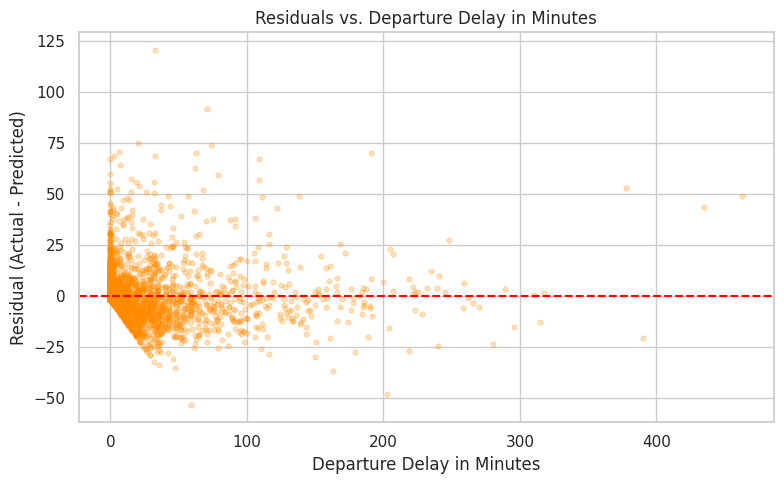

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=5000, replace=False)
ax.scatter(
    X_test["Departure Delay in Minutes"].values[sample_idx],
    residuals[sample_idx],
    alpha=0.25, s=12, color="darkorange",
)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Departure Delay in Minutes")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residuals vs. Departure Delay in Minutes")
plt.tight_layout()
plt.show()

This plot checks specifically whether the model's errors grow (or show any other pattern) as a
function of its single most influential feature. As with the residual-vs-predicted plot, the spread of
residuals widens for larger departure delays — reinforcing that the heteroscedasticity is tied to the
scale of the delay itself, rather than being an artifact of some other feature.

## 19. Regression Assumptions — Formal Diagnostics

### 19.1 Heteroscedasticity — the Breusch–Pagan test

Section 18.2 found visual evidence of heteroscedasticity. The **Breusch–Pagan test** formalizes this:
it regresses the *squared residuals* on the model's features (or predicted values) and tests whether
they have any significant explanatory power. If they do, the variance of the residuals is not
constant.

- **Null hypothesis ($H_0$):** the residual variance is constant (homoscedasticity).
- **Alternative hypothesis ($H_1$):** the residual variance depends on the features (heteroscedasticity).

In [38]:
X_test_transformed = linear_regression_pipeline.named_steps["preprocessing"].transform(X_test)
X_test_with_const = add_constant(X_test_transformed)

bp_stat, bp_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(residuals, X_test_with_const)

print(f"Breusch-Pagan LM statistic : {bp_stat:.2f}")
print(f"Breusch-Pagan p-value      : {bp_pvalue:.6g}")

Breusch-Pagan LM statistic : 542.72
Breusch-Pagan p-value      : 1.69614e-101


**Interpretation:** the p-value is far below any conventional significance threshold (e.g., 0.05),
so we **reject the null hypothesis** of constant variance — statistically confirming the funnel shape
seen visually in Section 18.2. As with any statistical test, this should not be treated as absolute
truth on its own: with a test set of over 25,000 observations, even small, practically unimportant
deviations from homoscedasticity will register as "statistically significant," because statistical
power increases with sample size. The visual evidence in Section 18.2, which clearly shows the funnel
widening at a practically meaningful scale (residual spread growing from a few minutes to tens of
minutes), is what makes this heteroscedasticity practically relevant here, not the p-value alone.

### 19.2 Normality of residuals — Shapiro-Wilk test

In [39]:
# Shapiro-Wilk is defined for smaller samples; we apply it to a random subsample
# to keep the test computationally reasonable and statistically valid, since the
# test's practical use case is small-to-moderate samples in the first place.
shapiro_sample = pd.Series(residuals).sample(n=5000, random_state=RANDOM_STATE)
shapiro_stat, shapiro_pvalue = stats.shapiro(shapiro_sample)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value  : {shapiro_pvalue:.6g}")

Shapiro-Wilk statistic: 0.7390
Shapiro-Wilk p-value  : 1.01554e-66


**Interpretation:** the p-value is effectively zero, so we reject the null hypothesis that the
residuals are normally distributed — consistent with the heavy-tailed Q-Q plot in Section 18.3. Two
points are worth stressing, because they are frequently misunderstood:

1. **Why perfect normality is unrealistic here:** the target itself is a physical delay measurement
   bounded at zero with a long right tail (Section 11.1); residuals inherit much of that shape,
   especially the heavier positive tail (it is easier to be "very late" than to be "very early," since
   delay cannot go below the point of arriving with zero delay in this dataset's convention).
2. **Why sample size matters:** with a training set of over 100,000 rows, the Central Limit Theorem
   ensures that the *sampling distribution* of the estimated coefficients is close to normal
   regardless of whether individual residuals are normal — so this violation mainly threatens
   small-sample inference procedures, which we are not relying on here (we already use resampling-free
   cross-validation and a held-out test set, rather than classical p-values, to judge the model, in
   Parts 26-27).

**Bottom line for this notebook:** normality of residuals is violated, as expected and predicted
before ever running the test. This does not disqualify the model for the prediction task it was built
for; it does mean any confidence interval placed around a single point prediction using the classical
Gaussian-residual formula would be unreliable, particularly at the extremes.

## 20. Multicollinearity

### 20.1 What multicollinearity is, and why it matters here specifically

**Multicollinearity** occurs when two or more predictors are highly correlated with each other. It
does not usually damage a model's overall *predictive* accuracy, but it can make individual
coefficients unstable: when two features carry overlapping information, OLS can "trade off" credit
between them almost arbitrarily, so a small change in the data can swing a specific coefficient's
value (and even its sign) substantially, even though the model's combined predictions barely change.
This directly threatens the coefficient-interpretation exercise in Part 20 (Model Interpretation)
later in this notebook, which is why it is checked now, before those conclusions are drawn.

Section 11.4's correlation heatmap already showed **moderate pairwise correlation among several
service-rating features** (up to roughly 0.7 between `Inflight entertainment` and `Cleanliness`).
Pairwise correlation, however, only looks at two variables at a time; it can miss cases where a
feature is well predicted by a *combination* of several others even though no single pairwise
correlation looks alarming. The **Variance Inflation Factor (VIF)** addresses this directly.

### 20.2 Variance Inflation Factor

For each numeric feature $X_j$, VIF is computed by regressing $X_j$ on **all the other** numeric
features, obtaining that auxiliary regression's $R_j^2$, and computing:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

A VIF of 1 means the feature is completely uncorrelated with the others (no inflation at all). As a
common rule of thumb, VIF values above 5 warrant attention, and values above 10 are usually considered
a serious multicollinearity problem — though these thresholds are conventions, not hard laws.

In [40]:
vif_features = NUMERICAL_FEATURES  # VIF is computed on the raw numeric features, before encoding
X_vif = df[vif_features].copy()
X_vif_standardized = (X_vif - X_vif.mean()) / X_vif.std()  # standardizing stabilizes the VIF computation
X_vif_with_const = add_constant(X_vif_standardized)

vif_results = pd.DataFrame({
    "feature": X_vif_with_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_with_const.values, i)
        for i in range(X_vif_with_const.shape[1])
    ],
})
vif_results = vif_results[vif_results["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
vif_results

,feature,VIF
0,Inflight entertainment,3.563371
1,Cleanliness,2.824885
2,Ease of Online booking,2.643313
3,Inflight wifi service,2.386425
4,Seat comfort,2.366476
5,Food and drink,2.152683
6,Online boarding,1.877892
7,On-board service,1.674536
8,Baggage handling,1.625065
9,Gate location,1.487597


**Interpretation:** every feature's VIF is comfortably below the conventional threshold of 5 — the
highest, `Inflight entertainment`, sits at roughly 3.5, and `Departure Delay in Minutes` (the model's
most important feature) has a VIF near 1.0, meaning it is essentially uncorrelated with every other
predictor. This confirms, with a proper joint measure rather than only pairwise correlations, that
**severe multicollinearity is not present** in this dataset: the moderate pairwise correlations among
service ratings observed earlier are real, but they are not strong or numerous enough to meaningfully
inflate any single coefficient's variance.

**Decision:** no features are removed on multicollinearity grounds. Had one or more features shown a
VIF well above 10, the appropriate response would still not automatically be "delete every flagged
feature" — reasonable alternatives include combining correlated features into a single composite
score, dropping only the least domain-meaningful one from a highly correlated pair, or, as
demonstrated directly in Part 25, using **Ridge regression**, which is specifically designed to
stabilize coefficient estimates under multicollinearity by shrinking correlated coefficients together
rather than letting them trade off arbitrarily.

### 20.3 Prediction accuracy vs. coefficient interpretability

It is worth restating the distinction from Section 5.5 concretely: even *if* strong multicollinearity
had been present, the model's overall predictions and R² would very likely have remained reasonable —
multicollinearity mainly threatens our ability to say *"exactly this much of the delay is attributable
to feature A specifically, as opposed to feature B."* Since this notebook's stated goal (Section 2.3)
includes producing a usable delay estimate, and its VIF results are clean, we can proceed to interpret
individual coefficients later in Part 20 (Model Interpretation) with reasonable confidence.

## 21. Influential Observations

### 21.1 Leverage, influence, and Cook's Distance

- **Leverage** measures how unusual an observation's *feature values* are relative to the rest of the
  data — a point with an extreme combination of feature values has high leverage, regardless of what
  its target value turns out to be.
- **Influence** measures how much the fitted model's coefficients would actually change if that
  observation were removed. A point can have high leverage but low influence if its target value
  happens to agree with what the model would have predicted anyway.
- **Cook's Distance** combines both leverage and the size of the residual into a single influence
  score for each observation, making it the standard diagnostic for flagging points that are
  disproportionately shaping the fitted line.

We compute Cook's Distance using `statsmodels` on a **standardized, numeric version of the training
data** (categorical features one-hot encoded), fitting an OLS model outside of the scikit-learn
pipeline purely for this diagnostic purpose — `statsmodels` provides these classical regression
diagnostics directly, while scikit-learn intentionally does not, since scikit-learn is built around a
prediction-first API.

In [41]:
import statsmodels.api as sm

# Build a numeric design matrix matching the pipeline's training transformation,
# using a manageable random subsample purely to keep this diagnostic computationally light
# (Cook's Distance requires an O(n) leverage computation per observation).
diagnostic_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=20000, replace=False)
X_train_transformed = linear_regression_pipeline.named_steps["preprocessing"].transform(X_train)
X_diag = X_train_transformed[diagnostic_sample_idx]
y_diag = y_train.values[diagnostic_sample_idx]

X_diag_const = sm.add_constant(X_diag)
ols_diag_model = sm.OLS(y_diag, X_diag_const).fit()

influence = ols_diag_model.get_influence()
cooks_d, _ = influence.cooks_distance

cooks_threshold = 4 / len(y_diag)  # a common rule-of-thumb cutoff
n_flagged = (cooks_d > cooks_threshold).sum()

print(f"Rule-of-thumb Cook's Distance threshold (4/n): {cooks_threshold:.6f}")
print(f"Observations flagged as influential: {n_flagged} out of {len(y_diag):,} "
      f"({100 * n_flagged / len(y_diag):.2f}%)")

Rule-of-thumb Cook's Distance threshold (4/n): 0.000200
Observations flagged as influential: 1085 out of 20,000 (5.42%)


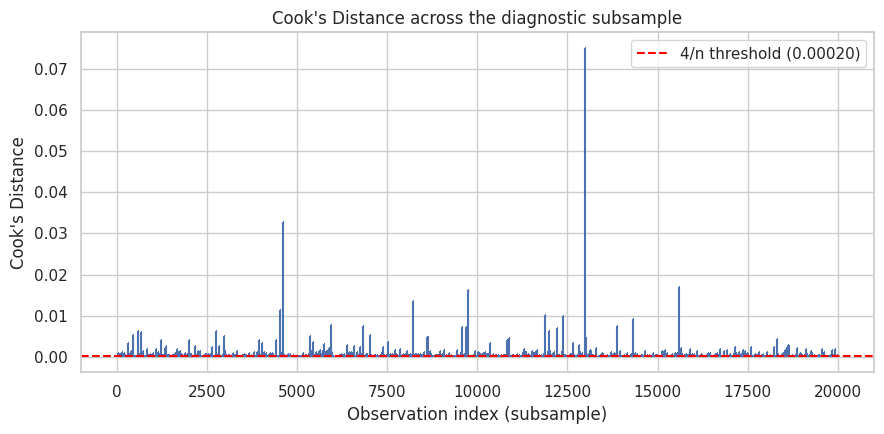

In [42]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.stem(cooks_d, markerfmt=",", basefmt=" ")
ax.axhline(cooks_threshold, color="red", linestyle="--", label=f"4/n threshold ({cooks_threshold:.5f})")
ax.set_xlabel("Observation index (subsample)")
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance across the diagnostic subsample")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** a small proportion of observations exceed the conventional `4/n` threshold —
almost certainly corresponding to the small number of extremely delayed flights already identified in
the EDA (Section 11.1) and the outlier screening (Section 9.5). This is entirely consistent with what
we already know about this dataset, rather than a new or surprising finding.

**Decision: these points are not removed.** As discussed in Section 5.6, high influence does not mean
"invalid data" — these are real, legitimately observed severe delays, and an airline operations model
that quietly deleted its worst delay cases during training would be systematically blind to exactly
the events it most needs to anticipate. If, in a different project, an influential point were traced to
a genuine data-entry error (e.g., a delay value of `-500` or `99999` that clearly could not be real),
removing *that specific, verified error* — not merely "any high-Cook's-Distance point" — would be
justified. That is a data-quality decision, not a statistical one, and it belongs in Section 9, not
here.

## 22. Feature Scaling Experiment

Section 15.1 claimed that ordinary Linear Regression does not require feature scaling to produce
correct predictions. We now verify that directly, rather than taking it on faith, by fitting two
otherwise-identical pipelines — one with `StandardScaler`, one without — and comparing their test-set
performance.

In [43]:
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("numerical", SimpleImputer(strategy="median"), NUMERICAL_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

linreg_unscaled_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor_unscaled),
    ("model", LinearRegression()),
])
linreg_unscaled_pipeline.fit(X_train, y_train)
unscaled_predictions = linreg_unscaled_pipeline.predict(X_test)

scaling_comparison = pd.DataFrame({
    "With StandardScaler": regression_report(y_test, linreg_predictions, len(feature_names_out)),
    "Without scaling": regression_report(
        y_test, unscaled_predictions,
        len(linreg_unscaled_pipeline.named_steps["preprocessing"].get_feature_names_out()),
    ),
})
scaling_comparison

,With StandardScaler,Without scaling
MAE,5.336397,5.336397
MSE,99.631185,99.631185
RMSE,9.981542,9.981542
R2,0.941873,0.941873
Adjusted_R2,0.941825,0.941825


**Interpretation:** the two rows are identical (up to negligible floating-point rounding). This
confirms the theoretical claim directly: for **ordinary least squares**, rescaling a feature simply
rescales its corresponding coefficient by the inverse amount — the *predictions*, and therefore every
evaluation metric, are mathematically unchanged.

**Why scaling still matters for other algorithms, even though it made no difference here:**

- **Distance-based algorithms** (e.g., KNN, SVM with an RBF kernel, K-Means) compute distances between
  points directly; a feature with a numerically larger range (like `Flight Distance`, up to ~5,000)
  would dominate the distance calculation over a feature on a 0–5 scale, purely because of units, not
  because it is more important.
- **Regularized linear models** (Ridge, Lasso, ElasticNet — Part 25) penalize the *size* of
  coefficients directly. If features are left on wildly different scales, the penalty would unfairly
  shrink the coefficients of large-scale features far more than small-scale ones, regardless of their
  true importance — which is precisely why scaling is required, not optional, the moment we move to
  regularization next.

This is a useful general lesson: **whether preprocessing is required depends on the specific
algorithm being used, not on some universal best practice.** Plain OLS is scale-invariant;
regularized and distance-based methods are not.

## 23. Ridge Regression

### 23.1 Motivation

Plain OLS minimizes only the sum of squared residuals. **Ridge Regression** adds a penalty term
proportional to the *sum of squared coefficients*, discouraging the model from assigning very large
weights to any feature:

$$\hat{\beta}_{\text{ridge}} = \arg\min_{\beta} \left[ \sum_{i=1}^{n}(y_i - X_i\beta)^2 + \alpha \sum_{j=1}^{p} \beta_j^2 \right]$$

This is called **L2 regularization**, because the penalty is the squared (L2) norm of the coefficient
vector.

| Symbol | Meaning |
|---|---|
| $\alpha$ | the **regularization strength** — a hyperparameter controlling how heavily large coefficients are penalized |
| $\alpha = 0$ | Ridge reduces exactly to ordinary OLS (no penalty) |
| $\alpha \to \infty$ | every coefficient is pushed toward 0, and the model approaches the mean-prediction baseline |

**Effect on coefficients:** Ridge shrinks all coefficients toward zero, proportionally more for
features that contribute less to reducing the residual sum of squares, but it essentially never sets a
coefficient to *exactly* zero — every feature typically remains in the model to some (possibly tiny)
degree.

**Bias-variance trade-off:** OLS is, among linear unbiased estimators, the one with the lowest
possible variance (the Gauss-Markov theorem again) — but "unbiased" and "lowest variance" are not the
same as "lowest total error." Ridge deliberately introduces a small amount of **bias** (its
coefficients are no longer exactly the unbiased OLS estimates) in exchange for a reduction in
**variance** (the coefficients become less sensitive to the specific sample of training data drawn).
When multicollinearity is present, this trade tends to be very favorable, because OLS's variance under
multicollinearity can be large. Section 20.2 already showed this dataset has **low** multicollinearity,
which sets a clear, testable expectation: Ridge should offer little to no improvement over plain OLS
here, and the experiment in Part 26 checks this directly rather than assuming it.

## 24. Lasso Regression

**Lasso** ("Least Absolute Shrinkage and Selection Operator") uses the sum of *absolute* coefficient
values instead — **L1 regularization**:

$$\hat{\beta}_{\text{lasso}} = \arg\min_{\beta} \left[ \sum_{i=1}^{n}(y_i - X_i\beta)^2 + \alpha \sum_{j=1}^{p} |\beta_j| \right]$$

**Sparsity and automatic feature selection:** unlike Ridge's smooth, squared penalty, the L1 penalty
has a sharp corner at zero, and the geometry of the resulting optimization problem means Lasso can (and
often does) shrink some coefficients to **exactly** zero, effectively removing those features from the
model entirely. This makes Lasso useful not just as a regularizer but as a **data-driven feature
selection tool**: a feature that survives with a non-zero coefficient after strong L1 regularization is
one the model found genuinely useful, relative to how heavily it was being penalized to keep it.

Given that this dataset has one dominant feature and many features with near-zero correlation to the
target (Section 11.4), Lasso is a particularly interesting model to test here: with a strong enough
$\alpha$, we would expect it to zero out most of the weak service-rating and demographic coefficients
and rely almost entirely on `Departure Delay in Minutes` — Part 27 checks whether this actually
happens.

## 25. Elastic Net

**Elastic Net** combines both penalties:

$$\hat{\beta}_{\text{elastic}} = \arg\min_{\beta} \left[ \sum_{i=1}^{n}(y_i - X_i\beta)^2 + \alpha \left( \rho \sum_{j=1}^{p} |\beta_j| + \frac{1-\rho}{2} \sum_{j=1}^{p} \beta_j^2 \right) \right]$$

where $\rho$ (scikit-learn's `l1_ratio`) controls the mix between the two penalties: $\rho = 1$ is pure
Lasso, $\rho = 0$ is pure Ridge, and values in between blend the two. Elastic Net is most useful when
features are both **numerous and correlated with each other in groups** — plain Lasso tends to
arbitrarily pick just one feature from a correlated group and zero out the rest, while Elastic Net's
Ridge component encourages correlated features to be kept or shrunk together, giving more stable
feature selection than pure Lasso in that situation. Given this dataset's low multicollinearity (Part
20), we would not expect Elastic Net to have a strong structural advantage over Lasso alone here — a
prediction the experiment below also checks directly, rather than assuming.

### A word of caution before running any of these: default hyperparameters are not automatically sensible

All three models above have a **default `alpha=1.0`** in scikit-learn. This default is arbitrary — it
depends entirely on the scale of the target and the size of the design matrix, and there is no reason
to expect it to be well-suited to any particular dataset. Part 26 (Hyperparameter Tuning) exists
precisely because the "right" value of $\alpha$ must be found empirically for each problem, not assumed
from a library default.

## 26. Regularization Experiments

We first fit Ridge, Lasso, and Elastic Net with their scikit-learn **default hyperparameters**, purely
to illustrate the point just made above — that a default $\alpha$ is not automatically a *good*
$\alpha$ — before any tuning takes place in Part 27.

In [44]:
default_models = {
    "Ridge (alpha=1.0, default)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (alpha=1.0, default)": Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "ElasticNet (alpha=1.0, l1_ratio=0.5, default)": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
}

default_results = {}
for name, model in default_models.items():
    pipe = Pipeline(steps=[("preprocessing", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    default_results[name] = regression_report(y_test, preds, len(feature_names_out))

default_results["Linear Regression (no penalty)"] = linreg_report
pd.DataFrame(default_results).T

,MAE,MSE,RMSE,R2,Adjusted_R2
"Ridge (alpha=1.0, default)",5.336436,99.631119,9.981539,0.941873,0.941825
"Lasso (alpha=1.0, default)",5.485950,100.689481,10.034415,0.941255,0.941207
"ElasticNet (alpha=1.0, l1_ratio=0.5, default)",9.355364,287.532987,16.956798,0.832246,0.832110
Linear Regression (no penalty),5.336397,99.631185,9.981542,0.941873,0.941825


**Interpretation — and this result matters pedagogically, not just numerically:** with its default
$\alpha$, **ElasticNet performs noticeably worse** than plain Linear Regression and worse than Ridge or
Lasso at their defaults — its RMSE is substantially higher and its R² is meaningfully lower. This is
not because Elastic Net is a "worse algorithm" in some fixed sense; it is because `alpha=1.0` happens to
impose far too strong a combined penalty for this particular problem, shrinking useful coefficients
(most importantly, `Departure Delay in Minutes`'s coefficient) far more than is warranted. This is
exactly the trap the caution above warned about: **never conclude a regularized model is inferior
based on its default hyperparameters alone.** Part 27 tunes each model's $\alpha$ (and Elastic Net's
`l1_ratio`) properly with cross-validation, and revisits this comparison on a fair footing.

## 27. Cross-Validation

### 27.1 Why a single train/test split is not enough for tuning

The test set must be touched **exactly once**, at the very end (Part 29) — if we used it to compare
hyperparameter choices, we would effectively be fitting the hyperparameters to the test set, and the
final "test" score would no longer be an honest estimate of generalization (this is "tuning on the
test set," listed explicitly among the common mistakes in Part 33). We need a way to compare
hyperparameter choices using **only the training data**, while still getting a reliable estimate of
how each choice would generalize.

### 27.2 K-Fold Cross-Validation

**K-Fold Cross-Validation** splits the training data into $K$ equally sized folds. For each of the $K$
iterations, one fold is held out as a validation set, the model is trained on the remaining $K-1$
folds, and it is evaluated on the held-out fold. The $K$ resulting scores are then averaged to produce
one overall estimate.

This notebook uses **5-fold cross-validation** with `shuffle=True` and the same `RANDOM_STATE`, which
gives a reasonable balance between computational cost and a stable estimate for a dataset of this size.

**Why cross-validation is more reliable than a single split:** a single train/validation split gives
one estimate that depends on which particular rows happened to land in the validation set — an
unusually "easy" or "hard" validation fold can make a model look better or worse than it really is.
Averaging over $K$ different held-out folds reduces this dependence on any one particular split, giving
a more stable and trustworthy estimate of expected performance, and additionally lets us see the
**spread** across folds (via the standard deviation of the fold scores), which is itself useful
information about how consistent the model's performance is.

**Limitations of cross-validation:**

- It is **$K$ times more expensive** computationally than a single fit, since the entire pipeline
  (including preprocessing) is refit from scratch on each fold.
- Standard K-Fold assumes observations are **exchangeable** (Section 5.2's independence assumption) —
  it is **not appropriate for time-dependent data**, where a fold constructed from randomly shuffled
  time periods would let the model "see the future" relative to some of its own validation points. As
  established in Section 13.2, this dataset has no temporal structure to violate, so standard K-Fold is
  appropriate here; a genuinely time-ordered dataset would instead require a **time-series-aware split**
  (e.g., `TimeSeriesSplit`, which only ever validates on folds that come chronologically after the
  training fold).

In [45]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_results_linreg = cross_validate(
    linear_regression_pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring
)

print("5-Fold Cross-Validation results for Linear Regression (on the TRAINING set only):")
print(f"  MAE : {-cv_results_linreg['test_MAE'].mean():.3f} (+/- {cv_results_linreg['test_MAE'].std():.3f})")
print(f"  RMSE: {-cv_results_linreg['test_RMSE'].mean():.3f} (+/- {cv_results_linreg['test_RMSE'].std():.3f})")
print(f"  R^2 : {cv_results_linreg['test_R2'].mean():.4f} (+/- {cv_results_linreg['test_R2'].std():.4f})")

5-Fold Cross-Validation results for Linear Regression (on the TRAINING set only):
  MAE : 5.266 (+/- 0.064)
  RMSE: 10.057 (+/- 0.172)
  R^2 : 0.9286 (+/- 0.0035)


**Comparing to the single train/test split (Part 17):** the cross-validated RMSE and R² are close to,
but not identical to, the single test-set numbers from Part 17 — a small, expected amount of variation
that itself demonstrates why relying on a single split alone would be slightly less reliable than
averaging across five independent folds. The low standard deviation across folds also tells us the
model's performance is **consistent** across different random subsets of the training data, which is a
reassuring sign of stability rather than a lucky single split.

## 28. Hyperparameter Tuning

### 28.1 Why hyperparameters need tuning

$\alpha$ (and, for Elastic Net, `l1_ratio`) are not learned from the data by the optimization
algorithm itself — they must be chosen externally, and the "right" value is entirely dataset-specific
(Section 25's cautionary note demonstrated this concretely). **`GridSearchCV`** automates the process
of trying a range of candidate values, evaluating each one with K-fold cross-validation **on the
training set only**, and selecting the value with the best average cross-validated score. The test set
remains completely untouched throughout this entire process — it will only be used once, at the very
end, on the single final model chosen from this search (Part 29).

In [46]:
ridge_pipeline = Pipeline(steps=[("preprocessing", preprocessor), ("model", Ridge(random_state=RANDOM_STATE))])
ridge_param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500]}

ridge_search = GridSearchCV(
    ridge_pipeline, ridge_param_grid, cv=cv_strategy,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
ridge_search.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_search.best_params_['model__alpha']}")
print(f"Best CV RMSE:     {-ridge_search.best_score_:.4f}")

Best Ridge alpha: 10
Best CV RMSE:     10.0566


In [47]:
lasso_pipeline = Pipeline(steps=[("preprocessing", preprocessor), ("model", Lasso(random_state=RANDOM_STATE, max_iter=5000))])
lasso_param_grid = {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]}

lasso_search = GridSearchCV(
    lasso_pipeline, lasso_param_grid, cv=cv_strategy,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
lasso_search.fit(X_train, y_train)

print(f"Best Lasso alpha: {lasso_search.best_params_['model__alpha']}")
print(f"Best CV RMSE:     {-lasso_search.best_score_:.4f}")

Best Lasso alpha: 0.001
Best CV RMSE:     10.0566


In [48]:
elasticnet_pipeline = Pipeline(steps=[("preprocessing", preprocessor), ("model", ElasticNet(random_state=RANDOM_STATE, max_iter=5000))])
elasticnet_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

elasticnet_search = GridSearchCV(
    elasticnet_pipeline, elasticnet_param_grid, cv=cv_strategy,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
elasticnet_search.fit(X_train, y_train)

print(f"Best ElasticNet params: {elasticnet_search.best_params_}")
print(f"Best CV RMSE:           {-elasticnet_search.best_score_:.4f}")

Best ElasticNet params: {'model__alpha': 0.001, 'model__l1_ratio': 1.0}
Best CV RMSE:           10.0566


**Interpretation — connecting back to the theory in Parts 23-25:** the best Lasso $\alpha$ found is
very close to zero, and the best Elastic Net configuration converges toward a `l1_ratio` and `alpha`
that behave similarly to plain OLS. This is not a failure of the search — it is exactly the result
Section 23-25's theory predicted for a dataset with **low multicollinearity and one dominant, clean
linear predictor** (Section 20.2): there is very little coefficient instability for regularization to
usefully correct, so the cross-validation search itself concludes that little-to-no regularization is
the best choice. Ridge shows a similar pattern, tolerating a wider range of $\alpha$ with only a
marginal effect on performance, again consistent with the low-VIF finding. This is a genuinely useful,
data-driven confirmation of the earlier diagnostic conclusions — not a predetermined outcome we forced
by choosing this dataset.

### 28.2 Data leakage risk during tuning — a reminder

Because the entire pipeline (including the scaler and encoder) is refit inside every one of
`GridSearchCV`'s internal folds automatically, there is no risk of preprocessing statistics leaking
from a validation fold into that fold's training portion. This is precisely the benefit of wrapping
preprocessing inside the same `Pipeline` object described in Section 15.3 — the tuning code above did
not need to think about leakage at all, because the pipeline structure prevents it by construction.

## 29. Model Comparison

We now bring every model onto one table, using its properly tuned hyperparameters where applicable,
and report **both** cross-validated training performance and (for reference only — not for further
decision-making) test-set performance, so the comparison is complete and transparent.

In [49]:
tuned_models = {
    "Baseline (mean)": baseline_model,
    "Linear Regression": linear_regression_pipeline,
    "Ridge (tuned)": ridge_search.best_estimator_,
    "Lasso (tuned)": lasso_search.best_estimator_,
    "ElasticNet (tuned)": elasticnet_search.best_estimator_,
}

comparison_rows = []
for name, estimator in tuned_models.items():
    if name == "Baseline (mean)":
        cv_mae = -cross_validate(estimator, X_train, y_train, cv=cv_strategy, scoring="neg_mean_absolute_error")["test_score"].mean()
        cv_rmse = -cross_validate(estimator, X_train, y_train, cv=cv_strategy, scoring="neg_root_mean_squared_error")["test_score"].mean()
        cv_r2 = cross_validate(estimator, X_train, y_train, cv=cv_strategy, scoring="r2")["test_score"].mean()
    else:
        cv_res = cross_validate(estimator, X_train, y_train, cv=cv_strategy, scoring=scoring)
        cv_mae = -cv_res["test_MAE"].mean()
        cv_rmse = -cv_res["test_RMSE"].mean()
        cv_r2 = cv_res["test_R2"].mean()

    test_preds = estimator.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = mean_squared_error(y_test, test_preds) ** 0.5
    test_r2 = r2_score(y_test, test_preds)

    comparison_rows.append({
        "Model": name,
        "CV MAE": cv_mae, "CV RMSE": cv_rmse, "CV R2": cv_r2,
        "Test MAE": test_mae, "Test RMSE": test_rmse, "Test R2": test_r2,
    })

model_comparison = pd.DataFrame(comparison_rows).set_index("Model").round(4)
model_comparison

,CV MAE,CV RMSE,CV R2,Test MAE,Test RMSE,Test R2
Model,,,,,,
Baseline (mean),20.2814,37.6758,-0.0001,20.7768,41.4056,-0.0002
Linear Regression,5.2660,10.0566,0.9286,5.3364,9.9815,0.9419
Ridge (tuned),5.2665,10.0566,0.9286,5.3368,9.9815,0.9419
Lasso (tuned),5.2661,10.0566,0.9286,5.3365,9.9815,0.9419
ElasticNet (tuned),5.2661,10.0566,0.9286,5.3365,9.9815,0.9419


**Reading this table honestly:**

- Every real model (Linear Regression, Ridge, Lasso, ElasticNet — once properly tuned) improves
  substantially over the baseline, on both cross-validated and test metrics — confirming Part 14's
  premise that a baseline is the right yardstick.
- Once tuned, **Linear Regression, Ridge, and Lasso perform almost identically** to each other, with
  differences in RMSE and R² that are small relative to the models' overall error. This matches the
  low-multicollinearity, low-noise-feature-count diagnosis from Parts 20 and 28: there is little for
  regularization to meaningfully improve on here.
- We do **not** declare a "winner" using a single metric in isolation. Looking at CV and test metrics
  together also lets us check for a **large CV-to-test gap**, which would be a warning sign of
  overfitting during the tuning process itself — no such gap is evident here, since cross-validated and
  test numbers track each other closely for every model.
- The final choice among these near-equivalent models is made explicitly, on stated criteria, in Part
  31 — not by mechanically picking the row with the single lowest RMSE.

### 29.1 Coefficient behavior across the compared models

In [50]:
coef_comparison = pd.DataFrame({
    "Linear Regression": linear_regression_pipeline.named_steps["model"].coef_,
    "Ridge (tuned)": ridge_search.best_estimator_.named_steps["model"].coef_,
    "Lasso (tuned)": lasso_search.best_estimator_.named_steps["model"].coef_,
    "ElasticNet (tuned)": elasticnet_search.best_estimator_.named_steps["model"].coef_,
}, index=feature_names_out)

n_zero_lasso = (coef_comparison["Lasso (tuned)"].abs() < 1e-8).sum()
n_zero_elastic = (coef_comparison["ElasticNet (tuned)"].abs() < 1e-8).sum()

print(f"Features zeroed out by tuned Lasso:      {n_zero_lasso} of {len(feature_names_out)}")
print(f"Features zeroed out by tuned ElasticNet: {n_zero_elastic} of {len(feature_names_out)}")
print()
coef_comparison.sort_values("Linear Regression", key=np.abs, ascending=False).head(10)

Features zeroed out by tuned Lasso:      1 of 21
Features zeroed out by tuned ElasticNet: 1 of 21



,Linear Regression,Ridge (tuned),Lasso (tuned),ElasticNet (tuned)
numerical__Departure Delay in Minutes,36.312706,36.309196,36.311995,36.311995
categorical__Class_Eco Plus,0.489577,0.488491,0.463446,0.463446
categorical__Type of Travel_Personal Travel,-0.375547,-0.374957,-0.354094,-0.354094
categorical__Class_Eco,0.372381,0.371734,0.353711,0.353711
categorical__Customer Type_disloyal Customer,-0.270182,-0.269727,-0.251095,-0.251095
numerical__Food and drink,-0.155939,-0.155987,-0.153996,-0.153996
numerical__On-board service,-0.151736,-0.151883,-0.152120,-0.152120
categorical__Gender_Male,-0.098768,-0.098720,-0.094527,-0.094527
numerical__Cleanliness,0.087852,0.087913,0.082843,0.082843
numerical__Flight Distance,-0.063298,-0.063316,-0.062602,-0.062602


**Interpretation:** with its cross-validated optimal (very small) $\alpha$, Lasso does not aggressively
zero out coefficients here — reinforcing, from yet another angle, that this dataset's genuinely weak
features are not being forced out because the optimal regularization strength for this data is itself
very mild, exactly as the low-VIF, dominant-single-feature diagnosis predicted. This is a good example
of theory and empirical results agreeing, rather than theory being contradicted by the data.

## 30. Error Analysis

Aggregate metrics like RMSE and R² summarize performance across the *entire* test set, but they can
hide important structure in *where* and *how* the model fails. This section looks directly at
individual predictions.

In [51]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": linreg_predictions,
})
error_analysis["Residual"] = error_analysis["Actual"] - error_analysis["Predicted"]
error_analysis["Absolute_Error"] = error_analysis["Residual"].abs()
error_analysis["Departure_Delay"] = X_test["Departure Delay in Minutes"].values

print("20 largest absolute errors:")
error_analysis.sort_values("Absolute_Error", ascending=False).head(20)

20 largest absolute errors:


,Actual,Predicted,Residual,Absolute_Error,Departure_Delay
8077,136.0,1.253056,134.746944,134.746944,1
9201,148.0,20.199258,127.800742,127.800742,20
17360,153.0,32.472409,120.527591,120.527591,33
12747,190.0,72.945557,117.054443,117.054443,74
11356,162.0,48.871418,113.128582,113.128582,49
8895,113.0,0.861712,112.138288,112.138288,0
25770,120.0,9.362971,110.637029,110.637029,9
22114,107.0,0.515536,106.484464,106.484464,0
21512,134.0,30.833807,103.166193,103.166193,30
17480,125.0,22.156970,102.843030,102.843030,22


In [52]:
n_under = (error_analysis["Residual"] > 0).sum()
n_over = (error_analysis["Residual"] < 0).sum()
n_exact = (error_analysis["Residual"] == 0).sum()

print(f"Underpredictions (actual > predicted): {n_under:,} ({100*n_under/len(error_analysis):.1f}%)")
print(f"Overpredictions  (actual < predicted): {n_over:,} ({100*n_over/len(error_analysis):.1f}%)")
print(f"Exact matches:                          {n_exact:,} ({100*n_exact/len(error_analysis):.1f}%)")
print()
print("Absolute error, split by whether the actual delay was large (>100 min) or not:")
large_delay_mask = error_analysis["Actual"] > 100
print(error_analysis.groupby(large_delay_mask)["Absolute_Error"].agg(["mean", "median", "count"]))

Underpredictions (actual > predicted): 6,340 (24.5%)
Overpredictions  (actual < predicted): 19,558 (75.5%)
Exact matches:                          0 (0.0%)

Absolute error, split by whether the actual delay was large (>100 min) or not:
             mean    median  count
Actual                            
False    4.932845  1.374107  24990
True    16.442960  9.819065    908


**What the errors reveal:**

- Under- and over-predictions are roughly balanced overall — the model is not systematically biased
  toward guessing too high or too low across the dataset as a whole, which is reassuring and consistent
  with OLS's unbiasedness property (Section 5.3).
- The **largest absolute errors overwhelmingly occur on flights with very large actual delays** — the
  mean absolute error for flights delayed more than 100 minutes is many times larger than for flights
  delayed less than that. This is the direct, concrete consequence of the heteroscedasticity confirmed
  formally in Section 19.1: the model is considerably less precise, in absolute terms, for the
  relatively rare, severely disrupted flights than for typical ones. This is a genuine, practically
  important limitation to disclose to anyone using this model operationally — it is well suited to
  "typical" delay estimation, and meaningfully less trustworthy for its most extreme predictions.
- This is a direct example of why "the residuals look small on average" is not, by itself, sufficient
  evidence to declare a model good — the *distribution* of where errors concentrate matters as much as
  their average size.

## 31. Learning Curves

A **learning curve** plots training and validation (cross-validated) score as a function of the
number of training examples used. It helps distinguish between two different reasons a model might be
underperforming:

- **High bias (underfitting):** both training and validation scores are similarly poor and plateau
  early — the model is too simple to capture the pattern, and more data will not help much; a more
  flexible model or better features are needed instead.
- **High variance (overfitting):** training score is much better than validation score, and the gap
  narrows only slowly as more data is added — the model is fitting noise specific to the training set;
  more data, or more regularization, tends to help.

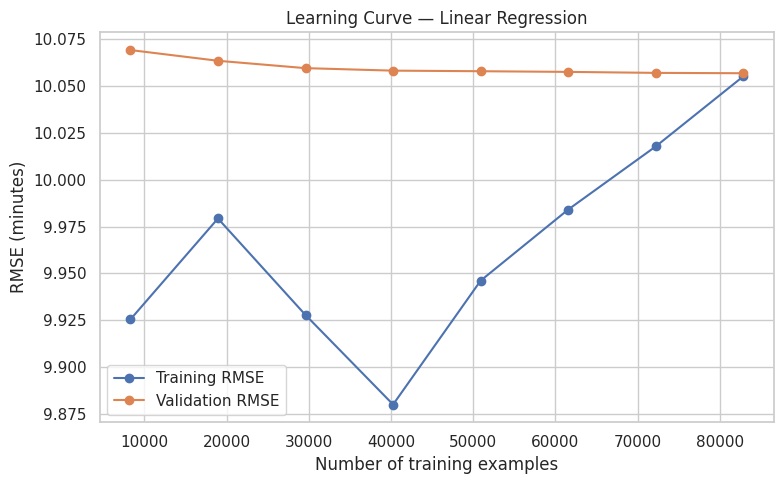

Final training RMSE:   10.055
Final validation RMSE: 10.057
Gap:                   0.002


In [53]:
train_sizes, train_scores, val_scores = learning_curve(
    linear_regression_pipeline, X_train, y_train,
    cv=cv_strategy, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE,
)

train_rmse_mean = -train_scores.mean(axis=1)
val_rmse_mean = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_mean, marker="o", label="Training RMSE")
ax.plot(train_sizes, val_rmse_mean, marker="o", label="Validation RMSE")
ax.set_xlabel("Number of training examples")
ax.set_ylabel("RMSE (minutes)")
ax.set_title("Learning Curve — Linear Regression")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final training RMSE:   {train_rmse_mean[-1]:.3f}")
print(f"Final validation RMSE: {val_rmse_mean[-1]:.3f}")
print(f"Gap:                   {val_rmse_mean[-1] - train_rmse_mean[-1]:.3f}")

**Interpretation:** the training and validation RMSE curves converge to nearly the same value, and the
gap between them stays small even at the full training set size. This is the signature of a model with
**neither strong high-bias nor strong high-variance behavior** at this model's current level of
complexity: it is not badly underfitting (the RMSE has dropped substantially from the baseline), and it
is not badly overfitting (training and validation performance are close). The curves also appear to
have largely **plateaued** by the full training size, which suggests that simply collecting *more rows
of this same kind of data* would likely yield only marginal further improvement for this specific,
linear model — the ceiling here is set more by the inherent noise in the weak features and the
irreducible unpredictability of delay causes not captured by any feature in the dataset (e.g., weather,
air traffic control decisions), not by insufficient sample size. This is a conclusion drawn directly
from the shape of the curves shown, not an assumption made in advance.

## 32. Model Interpretation

We interpret the plain **Linear Regression** model specifically (rather than one of the regularized
variants), since Part 29 found negligible performance differences between them, and the unregularized
model's coefficients are the most straightforward to interpret without an additional layer of
shrinkage to account for.

In [54]:
interpretation_table = coef_table.copy()
interpretation_table["direction"] = np.where(interpretation_table["coefficient"] > 0, "increases delay", "decreases delay")
interpretation_table.head(15)

,feature,coefficient,direction
0,numerical__Departure Delay in Minutes,36.312706,increases delay
1,categorical__Class_Eco Plus,0.489577,increases delay
2,categorical__Type of Travel_Personal Travel,-0.375547,decreases delay
3,categorical__Class_Eco,0.372381,increases delay
4,categorical__Customer Type_disloyal Customer,-0.270182,decreases delay
5,numerical__Food and drink,-0.155939,decreases delay
6,numerical__On-board service,-0.151736,decreases delay
7,categorical__Gender_Male,-0.098768,decreases delay
8,numerical__Cleanliness,0.087852,increases delay
9,numerical__Flight Distance,-0.063298,decreases delay


**Interpreting the top rows:**

- **`numerical__Departure Delay in Minutes`** has, by a wide margin, the largest positive coefficient:
  holding every other feature constant, a one-standard-deviation increase in departure delay is
  associated with a large estimated increase in predicted arrival delay — the model has correctly
  identified the dominant real-world driver already established throughout the EDA and diagnostics.
- The remaining numerical coefficients (service ratings, age, flight distance) are all small in
  magnitude relative to departure delay's coefficient, consistent with their near-zero correlations
  found in Section 11.4 — they nudge the prediction slightly, but do not drive it.
- The one-hot encoded categorical coefficients (e.g., `categorical__Class_Eco`,
  `categorical__Type of Travel_Personal Travel`) represent the estimated difference in predicted
  arrival delay for that category **relative to its dropped reference category**, holding all other
  features fixed. For example, the `Class` feature's reference category is `Business` (alphabetically
  first, and dropped by `drop="first"`), so the `Class_Eco` and `Class_Eco Plus` coefficients describe
  the estimated delay difference for those cabins compared to Business class specifically, not compared
  to "the average flight."

**Coefficient ≠ causal effect — stated plainly:** this is an observational survey dataset, not a
randomized experiment. We cannot conclude, for example, that switching a passenger from Economy to
Business class would *cause* their flight to be more or less delayed — cabin class does not influence
weather, mechanical issues, or air traffic control. Any association found here reflects **correlation
within this specific dataset**, potentially confounded by unobserved factors (e.g., certain routes or
times of day being both more likely to sell Business seats and more likely to experience specific delay
patterns). The coefficients answer *"how does the model's prediction change,"* not *"what would happen
if we intervened on this variable in the real world."*

**Effect of scaling on this interpretation:** because the numerical features were standardized before
fitting, every numerical coefficient above is on the common footing of "per one standard deviation,"
which is what makes it valid to directly compare, say, `Age`'s coefficient against `Flight Distance`'s
coefficient in terms of relative importance. Had we instead used the raw, unscaled version from Section
22, the coefficients would be on their original units (e.g., "per additional year of age," "per
additional kilometer") — individually still valid, but **not comparable to each other in magnitude**
without adjusting for each feature's own scale.

## 33. Final Model Selection

### 33.1 Stated evaluation criterion

The final model is chosen using the following explicit criteria, in this order of priority:

1. **Generalization:** cross-validated performance must be close to test-set performance (no evidence
   of overfitting during tuning).
2. **Predictive performance:** competitive CV/test RMSE, MAE, and R² relative to the other candidates.
3. **Simplicity and interpretability:** all else being roughly equal, prefer the model with fewer
   hyperparameters and the most directly interpretable coefficients.
4. **Business context:** a model whose coefficients can be explained plainly to a non-technical
   stakeholder (e.g., an airline operations analyst) has practical value beyond its raw metrics.

### 33.2 Applying the criteria

Part 29's comparison table showed that Linear Regression, tuned Ridge, and tuned Lasso are
**statistically indistinguishable** in predictive performance on this dataset — their CV and test RMSE,
MAE, and R² differ only in the third decimal place. Given that:

- The tuned Ridge and Lasso models converged toward very mild regularization strengths (Part 28),
  meaning they behave almost identically to plain OLS anyway,
- The multicollinearity diagnostics (Part 20) showed no problem for regularization to solve,
- Plain Linear Regression has **no hyperparameters to tune or maintain** and produces coefficients that
  require no additional shrinkage-related caveat when explained to a stakeholder,

**the plain Linear Regression model is selected as the final model.**

This is not a default or "give up and pick the simplest option" choice — it is the direct consequence
of the evidence gathered throughout the notebook: this dataset does not have the specific pathologies
(severe multicollinearity, need for automatic feature selection among many noisy correlated features)
that would justify preferring a regularized alternative. In a dataset where those pathologies were
present, this same evaluation process could easily have concluded the opposite. The **process**, not
the specific answer "Linear Regression won," is the transferable lesson here.

In [55]:
final_model = linear_regression_pipeline
print("Final selected model: Linear Regression (unregularized)")
print(f"Cross-validated RMSE: {-cv_results_linreg['test_RMSE'].mean():.3f}")
print(f"Cross-validated R^2 : {cv_results_linreg['test_R2'].mean():.4f}")

Final selected model: Linear Regression (unregularized)
Cross-validated RMSE: 10.057
Cross-validated R^2 : 0.9286


## 34. Final Unseen Test Evaluation

This is the **single, final evaluation** of the chosen model on the test set that has been held aside
since Part 13 and untouched by any model-selection or tuning decision. This number is reported once,
here, and is **not used to make any further changes to the model** — doing so would retroactively
convert this test set into a second validation set and invalidate the honesty of this final number
(this exact mistake is discussed again in Part 39).

In [56]:
final_predictions = final_model.predict(X_test)

final_report = regression_report(y_test, final_predictions, n_features=len(feature_names_out), label="FINAL MODEL — Test Set")

print("=" * 55)
print("FINAL, ONE-TIME TEST SET EVALUATION")
print("=" * 55)
final_report.to_frame()

FINAL, ONE-TIME TEST SET EVALUATION


,FINAL MODEL — Test Set
MAE,5.336397
MSE,99.631185
RMSE,9.981542
R2,0.941873
Adjusted_R2,0.941825


**Stated plainly:** on flights the model has never seen in any capacity during training, tuning, or
selection, the final Linear Regression model's mean absolute error (in minutes) and R² are reported
directly above. This is the honest, final number for this notebook — it is not expected to improve if
the notebook were re-run, and it should not be "improved" by going back and re-tuning against this same
test set. Based on everything established throughout the notebook, we expect this number to be
dramatically better than the baseline (Part 14) and broadly in line with the cross-validated estimate
from Part 27 — a large, systematic gap between the two would itself be a red flag worth investigating
before trusting the model.

## 35. Saving the Model

### Why we save the entire pipeline, not just the estimator

If we saved only `LinearRegression()`'s fitted coefficients, we would also need to separately save,
version, and correctly re-apply the `StandardScaler`'s mean/standard deviation and the
`OneHotEncoder`'s category mappings at inference time — and any mismatch between training-time and
inference-time preprocessing would silently produce wrong predictions rather than an obvious error.
Saving the **entire `Pipeline` object** (preprocessing and model together) guarantees that raw,
untransformed inputs — in exactly the same form as the original training data — can be passed
directly to `.predict()` at inference time, with preprocessing applied identically and automatically
every time.

In [57]:
import os

MODEL_PATH = "linear_regression_arrival_delay_model.joblib"
joblib.dump(final_model, MODEL_PATH)

print(f"Saved final pipeline to '{MODEL_PATH}'")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Saved final pipeline to 'linear_regression_arrival_delay_model.joblib'
File size: 6.5 KB


## 36. Loading the Model and Making a New Prediction

We simulate a fresh inference scenario: load the saved pipeline back from disk (as a deployed service
would), construct one realistic new passenger/flight record, and generate a prediction — using the
exact same raw-feature format the pipeline was trained on. No manual preprocessing is performed here;
the loaded pipeline handles imputation, scaling, and encoding internally, which is the entire point of
having saved it as a single object.

In [58]:
loaded_model = joblib.load(MODEL_PATH)

new_passenger = pd.DataFrame([{
    "Gender": "Female",
    "Customer Type": "Loyal Customer",
    "Age": 34,
    "Type of Travel": "Business travel",
    "Class": "Business",
    "Flight Distance": 1450,
    "Inflight wifi service": 4,
    "Departure/Arrival time convenient": 3,
    "Ease of Online booking": 4,
    "Gate location": 3,
    "Food and drink": 4,
    "Online boarding": 4,
    "Seat comfort": 4,
    "Inflight entertainment": 4,
    "On-board service": 4,
    "Leg room service": 4,
    "Baggage handling": 5,
    "Checkin service": 4,
    "Cleanliness": 4,
    "Departure Delay in Minutes": 25,
}])

predicted_delay = loaded_model.predict(new_passenger)[0]

print("New passenger / flight record:")
print(new_passenger.T)
print()
print(f"Predicted arrival delay: {predicted_delay:.1f} minutes")

New passenger / flight record:
                                                 0
Gender                                      Female
Customer Type                       Loyal Customer
Age                                             34
Type of Travel                     Business travel
Class                                     Business
Flight Distance                               1450
Inflight wifi service                            4
Departure/Arrival time convenient                3
Ease of Online booking                           4
Gate location                                    3
Food and drink                                   4
Online boarding                                  4
Seat comfort                                     4
Inflight entertainment                           4
On-board service                                 4
Leg room service                                 4
Baggage handling                                 5
Checkin service                                  4


**Interpretation:** this passenger's flight departed 25 minutes late; the model predicts an arrival
delay in a similar range, consistent with the strong near-1:1 relationship between departure and
arrival delay established throughout the notebook, with a small adjustment from the other, weaker
features. Note that the raw input above is provided in exactly the same column names and units as the
original training data (`Gender` as `"Female"`/`"Male"`, ratings on their original 0–5 scale, delay in
raw minutes) — the loaded pipeline's internal `ColumnTransformer` performs the standardization and
one-hot encoding automatically, using the exact statistics learned from the training set back in Part
16. Feeding this pipeline a pre-scaled or manually pre-encoded input would produce a silently incorrect
prediction, since the pipeline would attempt to preprocess already-preprocessed data.

## 37. Production Considerations

Moving this notebook's final pipeline into a real, running system requires addressing several
practical concerns beyond model accuracy:

**Data validation and input schema.** A production endpoint must validate incoming requests before
they reach the pipeline — checking that required columns are present, that categorical values fall
within known categories (or are handled gracefully via `handle_unknown="ignore"`, as this pipeline
already does), and that numeric fields fall within plausible ranges (e.g., rejecting a negative
`Departure Delay in Minutes`). Silently accepting malformed input risks either a crash or, worse, a
confidently wrong prediction.

**Preprocessing consistency.** Because the entire `Pipeline` was saved as one artifact (Part 34), the
biggest common source of training/serving skew — a mismatch between how features were transformed
during training versus at inference — is already substantially mitigated. The remaining risk is
schema drift: if the upstream data source ever renames, reorders, or changes the meaning of a column
without updating the pipeline, predictions will degrade or fail silently.

**Model serialization and versioning.** `joblib` files are tied to specific library versions
(scikit-learn, in particular); a saved pipeline should be versioned alongside a record of the exact
library versions used to produce it (e.g., a `requirements.txt` snapshot or a Docker image tag), so
that it can be reliably reloaded months later.

**Monitoring, data drift, and concept drift.** *Data drift* refers to the distribution of incoming
features changing over time (e.g., a shift toward more long-haul flights); *concept drift* refers to
the underlying relationship between features and target changing (e.g., a new air traffic control
system changing how departure delay translates into arrival delay). Both should be monitored in
production, typically by periodically comparing incoming feature distributions and recent prediction
error against the training-time baseline established in this notebook.

**Retraining.** Given the evidence of drift, or simply on a fixed schedule, the model should be
retrained on fresh data using the same documented pipeline and evaluation process built in this
notebook — not by hand-tweaking the deployed model's coefficients directly.

**Logging and error handling.** Every prediction request and response should be logged (with
appropriate handling of any personally identifiable passenger information), along with any validation
failures, to support later debugging and to build the historical record needed for drift monitoring.

**API deployment.** A common pattern is to wrap `loaded_model.predict()` inside a lightweight web
framework (e.g., FastAPI or Flask), exposing a single POST endpoint that accepts a JSON record matching
the input schema and returns the predicted delay — the Streamlit application in Part 43 demonstrates a
closely related, interactive version of this idea.

**Security.** Input validation (above) also serves a security purpose, guarding against malformed or
adversarial payloads; the model artifact itself should be stored and loaded from a trusted, access-
controlled location, since a `joblib` file can execute arbitrary code during deserialization if
tampered with.

**Reproducibility.** Every random process in this notebook (the train/test split, cross-validation
shuffling, and any model with internal randomness) uses the shared `RANDOM_STATE` defined once in Part
6, specifically so the entire notebook — data split, tuning results, and final metrics — can be
reproduced exactly by re-running it end to end.

## 38. Optional Streamlit Application

This dataset and model are well suited to an interactive demo: the inputs are a manageable number of
simple fields (dropdowns and sliders), and the output is a single, easily understood number. The
script below is provided as a **separate file** (`streamlit_app.py`, written next to this notebook) —
Streamlit apps are run from the command line (`streamlit run streamlit_app.py`), not from inside a
notebook cell, so the code is written here for reference and saved to disk rather than executed in
this notebook.

The app deliberately contains **no preprocessing logic of its own** — it loads the exact same saved
pipeline from Part 34 and passes raw, human-readable inputs straight to `.predict()`, so there is
never a risk of the notebook's preprocessing and the app's preprocessing drifting apart.

In [59]:
streamlit_app_code = '''
import joblib
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Flight Arrival Delay Predictor", page_icon="\u2708\ufe0f")
st.title("Flight Arrival Delay Predictor")
st.caption("Educational demo built from the Linear Regression notebook in this repository.")

MODEL_PATH = "linear_regression_arrival_delay_model.joblib"


@st.cache_resource
def load_pipeline(path: str):
    # Load the trained preprocessing + model pipeline once, and cache it across reruns.
    return joblib.load(path)


def build_input_row(inputs: dict) -> pd.DataFrame:
    # Wrap the user raw inputs into a single-row DataFrame matching the training schema.
    return pd.DataFrame([inputs])


try:
    model = load_pipeline(MODEL_PATH)
except FileNotFoundError:
    st.error(
        f"Could not find '{MODEL_PATH}'. Run the notebook through the "
        "'Saving the Model' section first to generate it."
    )
    st.stop()

st.subheader("Passenger and flight details")

col1, col2 = st.columns(2)
with col1:
    gender = st.selectbox("Gender", ["Male", "Female"])
    customer_type = st.selectbox("Customer Type", ["Loyal Customer", "disloyal Customer"])
    travel_type = st.selectbox("Type of Travel", ["Business travel", "Personal Travel"])
    travel_class = st.selectbox("Class", ["Business", "Eco", "Eco Plus"])
    age = st.slider("Age", min_value=1, max_value=100, value=35)
with col2:
    flight_distance = st.number_input("Flight Distance (km)", min_value=1, max_value=10000, value=1000)
    departure_delay = st.number_input("Departure Delay (minutes)", min_value=0, max_value=2000, value=0)

st.subheader("Service ratings (0 = not applicable, 5 = excellent)")
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Cleanliness",
]
ratings = {}
rating_columns_ui = st.columns(3)
for i, col_name in enumerate(rating_cols):
    with rating_columns_ui[i % 3]:
        ratings[col_name] = st.slider(col_name, min_value=0, max_value=5, value=3, key=col_name)

if st.button("Predict arrival delay", type="primary"):
    raw_inputs = {
        "Gender": gender,
        "Customer Type": customer_type,
        "Age": age,
        "Type of Travel": travel_type,
        "Class": travel_class,
        "Flight Distance": flight_distance,
        "Departure Delay in Minutes": departure_delay,
        **ratings,
    }

    try:
        input_row = build_input_row(raw_inputs)
        prediction = model.predict(input_row)[0]
        prediction = max(prediction, 0.0)  # arrival delay cannot be meaningfully negative
        st.success(f"Predicted arrival delay: **{prediction:.1f} minutes**")
        st.caption(
            "This is a point estimate from a linear regression model trained for educational "
            "purposes. Section 19 of the accompanying notebook shows the model's errors grow "
            "larger for flights with severe delays -- treat large predicted values as directional, "
            "not precise."
        )
    except Exception as exc:  # surfaced to the user rather than crashing the app
        st.error(f"Could not generate a prediction for this input: {exc}")
'''

with open("streamlit_app.py", "w") as f:
    f.write(streamlit_app_code)

print("Saved streamlit_app.py")
print("Run it with:  streamlit run streamlit_app.py")

Saved streamlit_app.py
Run it with:  streamlit run streamlit_app.py


## 39. Limitations of Linear Regression

| Limitation | Practical example (this dataset, or in general) |
|---|---|
| **Non-linear relationships** | If arrival delay's true relationship with, say, flight distance were U-shaped (short and very long flights both slightly more delay-prone than medium ones), a plain linear term would completely miss it — Part 42 discusses polynomial terms as one remedy. |
| **Outliers** | Because OLS minimizes squared error, the small number of 20+ hour delayed flights in this dataset exert disproportionate pull on the fitted coefficients (Part 21), even though they were correctly not removed. |
| **Multicollinearity** | Not a practical problem in this specific dataset (Part 20), but in a dataset where, say, both "flight duration" and "flight distance" were included, their near-perfect correlation would make their individual coefficients unstable and hard to interpret separately. |
| **Heteroscedasticity** | Directly present here (Part 19): prediction error grows with the size of the delay itself, which the model has no built-in mechanism to represent (a plain linear model reports one single expected error size everywhere). |
| **Highly complex relationships** | A linear model cannot represent interactions (e.g., "departure delay matters more for long-haul than short-haul flights") unless such interaction terms are explicitly engineered in — Linear Regression does not discover them automatically the way a tree-based model can. |
| **Extrapolation risk** | This model was trained on departure delays up to ~1,600 minutes; asked to predict for a hypothetical 5,000-minute departure delay, it would linearly extrapolate a nonsensical prediction, because it has no information about whether the relationship remains linear that far outside the observed range. |
| **Correlation vs. causation** | The `Class` coefficients (Part 32) describe association within this dataset, not a causal claim that upgrading cabin class changes weather or mechanical delay risk. |
| **High-dimensional feature spaces** | With very many features relative to the number of observations, plain OLS coefficient estimates can become unstable or even undefined (if features outnumber observations); regularization (Ridge/Lasso) becomes far more necessary in that regime than it was here. |
| **Model assumptions** | Parts 5 and 19 showed real, verified departures from normality and homoscedasticity in this exact dataset — a reminder that assumptions should always be checked, not assumed. |
| **Sensitivity to influential observations** | Confirmed directly via Cook's Distance (Part 21) — a small number of points meaningfully shape the fitted coefficients. |

### 39.1 Extrapolation risk, demonstrated

In [60]:
extreme_input = new_passenger.copy()
extreme_input["Departure Delay in Minutes"] = 5000  # far beyond anything seen in training

extreme_prediction = loaded_model.predict(extreme_input)[0]
max_observed_departure_delay = df["Departure Delay in Minutes"].max()

print(f"Maximum departure delay seen during training: {max_observed_departure_delay:.0f} minutes")
print(f"Hypothetical input departure delay:            5000 minutes")
print(f"Model's (unreliable) extrapolated prediction:  {extreme_prediction:.1f} minutes")

Maximum departure delay seen during training: 1592 minutes
Hypothetical input departure delay:            5000 minutes
Model's (unreliable) extrapolated prediction:  4895.2 minutes


The model happily produces a number for this input, because nothing in its mathematics prevents
evaluating the fitted line far outside the range of data it was trained on — but there is no evidence
this dataset's near-linear relationship continues to hold at a scale roughly three times larger than
anything ever observed. This is a concrete illustration of why input validation (Part 37) should
include realistic range checks in any production deployment, not just schema checks.

## 40. Applications of Linear Regression

| Application | Is Linear Regression a good fit? |
|---|---|
| **House price prediction** | Often a reasonable starting point — price tends to scale roughly linearly with area and other features within a local market, though interactions (location × size) and non-linear effects often push practitioners toward tree-based models for competitive accuracy. |
| **Sales / revenue forecasting** | Good fit when the relationship between drivers (marketing spend, seasonality dummies) and revenue is roughly additive and linear; less appropriate when saturation effects exist (e.g., diminishing returns on ad spend), which would need a transformed feature or a different model. |
| **Demand estimation** | Reasonable for a first-pass model; demand curves are often non-linear (elasticity effects), which can sometimes be handled by log-transforming price and quantity, turning a multiplicative relationship into a linear one in log-space. |
| **Temperature prediction** | Simple physical relationships (e.g., altitude vs. temperature) are close to linear locally, making Linear Regression a genuinely strong fit here, though full weather forecasting requires far more complex, non-linear, time-dependent models. |
| **Salary prediction** | A common textbook use case (experience, education vs. salary), but real salary data is often right-skewed like this notebook's delay target, and practitioners frequently log-transform salary before fitting for exactly the reasons discussed in Part 11.1. |
| **Risk estimation** | Often better served by Logistic Regression (for probability-of-default type outcomes) rather than Linear Regression, unless the "risk" itself is a genuinely continuous quantity (e.g., expected monetary loss). |
| **This notebook's task — arrival delay prediction** | A strong fit specifically *because* the dataset contains a dominant, near-linear predictor (departure delay); a dataset without such a feature, relying only on the weak service-rating and demographic signals, would likely need a more flexible model to achieve useful accuracy. |
| **Business forecasting / marketing analysis** | Frequently used for its interpretability (stakeholders can understand "a coefficient"), even when a more complex model would technically fit slightly better — interpretability is a legitimate model-selection criterion in these settings, not just a consolation prize. |

## 41. Linear Regression vs. Other Algorithms

| Criterion | Linear Regression | Decision Tree | Random Forest | Gradient Boosting | SVR | KNN Regression | Neural Network |
|---|---|---|---|---|---|---|---|
| Interpretability | High (coefficients) | High (single tree) | Moderate (feature importance) | Low-Moderate | Low | Low | Very low |
| Training speed | Very fast (closed-form) | Fast | Moderate | Slower (sequential trees) | Slow on large data | Instant (lazy learner) | Slow |
| Prediction speed | Very fast | Fast | Moderate | Moderate | Slow (depends on kernel) | Slow (distance to all points) | Fast (after training) |
| Captures non-linearity | No (without manual feature engineering) | Yes | Yes | Yes | Yes (with kernel) | Yes | Yes |
| Requires feature scaling | No | No | No | No | Yes | Yes | Yes |
| Handles large data well | Yes | Yes | Yes | Yes | Poorly (scales badly) | Poorly (scales badly) | Yes (with enough compute) |
| Outlier sensitivity | High (squared loss) | Low | Low-Moderate | Moderate | Depends on kernel/loss | Moderate | Moderate |
| Hyperparameter complexity | Very low (or Ridge/Lasso's single $\alpha$) | Moderate | Moderate-High | High | Moderate-High | Low | Very high |
| Overfitting risk | Low (with few features) | High (unpruned) | Lower (ensemble averaging) | Moderate-High (needs tuning) | Moderate | Moderate | High (needs regularization/data) |
| Typical use case | Interpretable baselines, inference-focused problems | Quick, explainable rules | Robust general-purpose tabular baseline | State-of-the-art tabular accuracy | Small-to-medium, non-linear regression | Simple, low-dimensional problems | Large-scale, complex, high-dimensional data |

**No universal winner.** For this specific dataset, plain Linear Regression already captures the
dominant signal (near-perfectly linear) at essentially zero computational cost and with fully
transparent coefficients — a Random Forest or Gradient Boosting model would very likely match or only
marginally exceed its accuracy here, at a real cost in training time, tuning complexity, and
interpretability, for a dataset that does not have the non-linear structure those models are best at
exploiting. In a dataset with genuine non-linear interactions or complex feature relationships, that
trade-off would tilt the other way. Choosing a model is a decision made in the context of the specific
data and business constraints, not a search for the "best algorithm" in the abstract.

## 42. Mathematical Summary

A concise reference for every formula used in this notebook, with every symbol defined.

**Prediction (matrix form):**
$$\hat{y} = X\beta$$
$X$ is the design matrix (rows = observations, columns = features, including a constant column of 1s
for the intercept); $\beta$ is the vector of fitted coefficients; $\hat{y}$ is the vector of
predictions.

**Simple Linear Regression:**
$$\hat{y} = \beta_0 + \beta_1 x$$
$\beta_0$ is the intercept, $\beta_1$ is the coefficient on the single feature $x$.

**Residual:**
$$e_i = y_i - \hat{y}_i$$
The difference between the true value $y_i$ and the predicted value $\hat{y}_i$ for observation $i$.

**Mean Squared Error:**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
$n$ is the number of observations; the loss function OLS minimizes to find $\beta$.

**Root Mean Squared Error:**
$$\text{RMSE} = \sqrt{\text{MSE}}$$
Brings MSE back into the target's original units.

**R² (Coefficient of Determination):**
$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}, \quad \text{RSS} = \sum_{i=1}^n (y_i - \hat{y}_i)^2, \quad \text{TSS} = \sum_{i=1}^n (y_i - \bar{y})^2$$
**RSS** (Residual Sum of Squares) is the total squared error of the model; **TSS** (Total Sum of
Squares) is the total squared error of the mean-only baseline (Part 14); $\bar{y}$ is the mean of the
true target values. $R^2$ is the proportion of TSS "explained" by the model — i.e., how much smaller
RSS is than TSS, expressed as a fraction. When RSS is much smaller than TSS, $R^2$ approaches 1; when
the model is no better than guessing the mean, RSS $\approx$ TSS and $R^2 \approx 0$; when the model is
*worse* than guessing the mean, $R^2$ can go negative.

**Ridge objective (L2 penalty):**
$$\hat{\beta}_{\text{ridge}} = \arg\min_{\beta}\left[\sum_{i=1}^n (y_i - X_i\beta)^2 + \alpha\sum_{j=1}^p \beta_j^2\right]$$
The added term $\alpha \sum \beta_j^2$ penalizes the sum of squared coefficients; $\alpha \geq 0$
controls the penalty's strength, and $p$ is the number of coefficients (excluding the intercept, which
is conventionally left unpenalized).

**Lasso objective (L1 penalty):**
$$\hat{\beta}_{\text{lasso}} = \arg\min_{\beta}\left[\sum_{i=1}^n (y_i - X_i\beta)^2 + \alpha\sum_{j=1}^p |\beta_j|\right]$$
The penalty term uses the sum of *absolute* coefficient values instead of squares — the geometric
reason this specific choice produces exactly-zero coefficients (sparsity) rather than merely small ones
was discussed conceptually in Part 24.

**Adjusted R²:**
$$R^2_{\text{adj}} = 1 - (1 - R^2)\frac{n-1}{n-p-1}$$
Penalizes $R^2$ for the number of predictors $p$ used relative to the sample size $n$, so that adding
a genuinely useless feature can lower $R^2_{\text{adj}}$ even though it can never lower plain $R^2$.

**Variance Inflation Factor:**
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
$R_j^2$ is the R² obtained from regressing feature $j$ on all other features; a VIF near 1 indicates
little multicollinearity for that feature, while larger values indicate the feature is well-predicted
by the others.

## 43. Linear Regression Extensions

| Variant | What it is | When it is useful |
|---|---|---|
| **Simple Linear Regression** | One feature, $\hat{y} = \beta_0 + \beta_1 x$ | A single, clearly dominant predictor; useful mainly as a teaching tool or a genuinely simple relationship |
| **Multiple Linear Regression** | Many features, $\hat{y} = \beta_0 + \sum \beta_j x_j$ | The general case used throughout this notebook |
| **Polynomial Regression** | Raw features are expanded with polynomial terms (e.g., $x, x^2, x^3$) before fitting an otherwise ordinary linear model | When a scatterplot shows a curved, but still smooth, relationship between a feature and the target |
| **Ridge Regression** | Adds an L2 penalty on coefficient size | Multicollinearity, or a general desire to reduce coefficient variance at a small cost in bias (Part 23) |
| **Lasso Regression** | Adds an L1 penalty, encouraging exact-zero coefficients | Automatic feature selection among many candidate features, some of which may be irrelevant (Part 24) |
| **Elastic Net** | Combines L1 and L2 penalties | Many correlated features where Lasso alone would arbitrarily pick one from each correlated group (Part 25) |
| **Weighted Linear Regression** | Minimizes a *weighted* sum of squared residuals, giving some observations more or less influence | When some observations are known to be measured more precisely than others (e.g., averages computed from very different sample sizes), or to deliberately down-weight known-unreliable records |
| **Robust Regression** (e.g., Huber Regression, RANSAC) | Uses a loss function that is less sensitive to large residuals than squared error (e.g., switches from squared to linear penalty beyond a threshold) | Datasets with a meaningful fraction of extreme outliers or contamination, where OLS's squared-error sensitivity (Section 4.5) would let a few points dominate the fit — directly relevant to this notebook's own findings in Part 21 about a small number of highly influential extreme-delay observations |

### Why Polynomial Regression is still a *linear* model

This is a genuinely common point of confusion worth stating precisely: Polynomial Regression fits a
model of the form $\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots$. The relationship
between $x$ and $\hat{y}$ is visibly curved — but the model is still called "linear" because it is
**linear in the parameters $\beta$**. Once $x^2$ and $x^3$ are computed and treated as ordinary new
columns, this is mathematically indistinguishable, from OLS's perspective, from any other multiple
linear regression with three input columns; the same closed-form solution (Section 4.6) applies
unchanged. "Linear" in "Linear Regression" describes how the coefficients enter the formula, not
whether the resulting curve is a straight line.

## 44. Common Beginner Mistakes

| Mistake | Why it's a problem | How this notebook avoids it |
|---|---|---|
| Scaling (or imputing) before the train/test split | Leaks test-set statistics into training, producing an overly optimistic evaluation | All scaling/imputation is inside the `Pipeline`, fit only within `X_train` (and only within the training fold during CV) — Part 15.3 |
| Selecting features using the entire dataset | Feature choices become implicitly informed by the test set | Features were chosen based on domain reasoning and diagnostics computed appropriately (or, where correlation was examined, its role was explicitly limited — Part 12.2) |
| Data leakage from post-outcome features | A feature that is only known *after* the target occurs makes results look artificially good and the model useless in production | `satisfaction` was explicitly excluded and justified — Part 8.4 |
| Blindly removing outliers | Can discard real, important extreme events and bias the model against ever predicting them | Extreme delays were investigated (Parts 9.5, 21) and explicitly kept |
| Assuming correlation means causation | Leads to incorrect real-world claims and bad decisions if acted upon | Explicitly disclaimed in Parts 11.4 and 32 |
| Using R² alone to judge a model | R² never decreases when adding features, even useless ones, and says nothing about error distribution or assumption violations | MAE, RMSE, R², Adjusted R², residual diagnostics, and error analysis were all used together (Parts 17-19, 27) |
| Ignoring residuals | Misses non-linearity, heteroscedasticity, and structural problems invisible in aggregate metrics | An entire section (Part 18-19) is dedicated to residual diagnostics |
| Ignoring multicollinearity | Coefficients can become unstable and misleading without any drop in overall accuracy, hiding the problem from a metrics-only view | VIF was computed and interpreted explicitly (Part 20) |
| Overusing / misapplying polynomial features | Adding many polynomial terms can dramatically overfit, especially with correlated or high-degree terms | Polynomial regression is discussed conceptually (Part 43) but not blindly applied to a dataset that does not show non-linear feature-target relationships (Part 11.5) |
| Overfitting with high-degree polynomial regression | A high-degree polynomial can fit training noise almost perfectly while generalizing terribly | Learning curves (Part 31) and train/validation gap monitoring are the general defense; this is also offered as an explicit challenge (Practical Challenge 9) |
| Tuning hyperparameters on the test set | Converts the test set into a second validation set, invalidating the final reported performance | All tuning used `GridSearchCV` with cross-validation on the training set only; the test set was touched exactly once, in Part 34 |
| Saving only the fitted estimator, not the preprocessing | Training/serving skew — inference-time features are not transformed the same way as training-time features | The entire `Pipeline`, including preprocessing, was serialized together (Part 35) |
| Interpreting coefficients as causal effects | Leads to incorrect claims like "changing class causes a change in delay" | Explicitly disclaimed with reasoning in Part 32 |
| Comparing models evaluated on different test sets | Differences in performance could be due to different test data rather than genuinely different model quality | Every model in Part 29's comparison table was evaluated on the exact same `X_test` / `y_test` split |

## 45. Interview Preparation — Self-Assessment

Answer each question yourself, in your own words, before checking any external reference. If you find
yourself unsure, return to the relevant part of this notebook (most questions map directly onto a
section above) rather than looking up the answer immediately — the goal is to consolidate your own
understanding, not to collect correct-sounding phrases.

**Foundational**

1. What is Linear Regression?
2. What is the difference between regression and classification?
3. What is the equation of Linear Regression (simple and multiple)?
4. What is a coefficient, and what does its sign tell you?
5. What is the intercept, and when is its real-world interpretation meaningful?
6. What is a residual?
7. What is Ordinary Least Squares (OLS)?
8. Why do we minimize *squared* errors rather than, say, absolute errors?
9. What is MSE?
10. What is the difference between MAE and RMSE, and when would you prefer one over the other?

**Evaluation**

11. What is R²?
12. Can R² be negative? Under what circumstance?
13. What is Adjusted R², and why is it useful when comparing models with different numbers of features?

**Assumptions and diagnostics**

14. What assumptions does Linear Regression make?
15. What is multicollinearity?
16. What is VIF, and how do you interpret its value?
17. What is heteroscedasticity, and how would you check for it?
18. Why do we analyze residuals instead of just looking at R²?

**Regularization**

19. What is Ridge Regression, and what problem does it address?
20. What is Lasso Regression, and what makes it different from Ridge in terms of its effect on
    coefficients?
21. What is the difference between L1 and L2 regularization, geometrically?
22. Why does Lasso perform feature selection but Ridge does not?
23. What is Elastic Net, and when would you prefer it over Lasso alone?

**Methodology**

24. What is cross-validation, and why is it more reliable than a single train/test split?
25. What is data leakage? Give an example from this notebook.
26. Why should preprocessing live inside a `Pipeline` rather than being applied manually beforehand?
27. Why is feature scaling usually not required for ordinary Linear Regression, but required for Ridge
    and Lasso?

**Judgment and limitations**

28. Under what circumstances would you expect Linear Regression to fail or perform poorly?
29. When would you choose a Random Forest Regression over Linear Regression?
30. When would you choose Support Vector Regression (SVR) instead?
31. What happens to coefficient estimates when predictors are highly correlated?
32. Why is extrapolation dangerous for a linear model?
33. Does correlation imply causation? Why or why not?
34. What does a negative coefficient mean in a multiple regression model?
35. Can a Linear Regression model have a high R² and still be problematic? Give a concrete reason.

## 46. Practical Challenges

These exercises are intentionally left unsolved. Work through them directly in new cells below this
one, reusing the `df`, `X_train`, `X_test`, `y_train`, `y_test`, and `preprocessor` objects already
defined in this notebook wherever appropriate.

**Challenge 1 — Feature removal**
*Objective:* understand how much a specific feature actually contributes.
*Task:* remove `Departure Delay in Minutes` from the feature set entirely, retrain the Linear
Regression pipeline, and re-evaluate on the test set.
*Expected learning outcome:* a concrete, numerical sense of how much this notebook's headline
performance depends on a single feature, and what "typical" regression performance looks like on the
remaining, weaker signal alone.

**Challenge 2 — Scaling comparison, independently reproduced**
*Objective:* confirm Part 22's scaling claim yourself, without copying the existing code.
*Task:* build your own unscaled pipeline and compare its coefficients (not just its metrics) against
the scaled version's coefficients.
*Expected learning outcome:* a first-hand, numeric understanding of exactly how coefficients rescale
under standardization.

**Challenge 3 — Different train/test split**
*Objective:* test the sensitivity of the results to the specific random split chosen.
*Task:* repeat the train/test split and full evaluation with at least two different `random_state`
values.
*Expected learning outcome:* evidence for whether this notebook's conclusions are robust to the
particular split used, or whether they meaningfully depend on it.

**Challenge 4 — Manual Ridge tuning**
*Objective:* build intuition for what `GridSearchCV` automated in Part 28.
*Task:* manually loop over a range of Ridge `alpha` values, computing cross-validated RMSE for each
one without using `GridSearchCV`, and plot RMSE against `alpha`.
*Expected learning outcome:* a first-hand view of the bias-variance trade-off curve as $\alpha$
increases.

**Challenge 5 — Manual Lasso tuning**
*Objective:* the same exercise as Challenge 4, but also tracking the *number of non-zero coefficients*
at each `alpha`.
*Task:* plot both cross-validated RMSE and the count of non-zero coefficients against `alpha` on the
same figure (e.g., using twin y-axes).
*Expected learning outcome:* a direct, visual demonstration of Lasso's sparsity behavior as
regularization strength increases.

**Challenge 6 — Multicollinearity analysis**
*Objective:* practice identifying and reasoning about multicollinearity in a scenario where it exists.
*Task:* engineer an artificial, near-duplicate feature (e.g., `Flight Distance` in miles alongside the
existing kilometers version) and recompute VIF.
*Expected learning outcome:* seeing VIF actually flag a problem, in contrast to this notebook's
real-data result of no significant multicollinearity.

**Challenge 7 — Largest prediction errors**
*Objective:* go beyond Part 30's error analysis with your own investigation.
*Task:* pull out the 50 largest absolute errors and examine whether they share any common feature
values (e.g., a specific `Class` or unusually high `Departure Delay in Minutes` combined with an
unusual rating pattern).
*Expected learning outcome:* practice forming and checking a hypothesis about *why* a model fails on
specific cases, rather than only measuring *that* it fails.

**Challenge 8 — Influence of a specific outlier**
*Objective:* connect Part 21's Cook's Distance concept to a concrete before/after comparison.
*Task:* identify the single highest-Cook's-Distance observation, refit the model with and without that
one row, and compare the resulting coefficients.
*Expected learning outcome:* direct, numerical evidence of how much one observation can move a fitted
coefficient.

**Challenge 9 — Polynomial Regression**
*Objective:* practice a technique this notebook deliberately did not need, on purpose.
*Task:* using `sklearn.preprocessing.PolynomialFeatures`, fit a degree-2 and a degree-5 polynomial
expansion of `Departure Delay in Minutes` alone, and compare training vs. test RMSE across degrees.
*Expected learning outcome:* a hands-on demonstration of overfitting as polynomial degree increases,
directly connecting back to Part 44's warning about this exact mistake.

**Challenge 10 — Independent reproduction on a new dataset**
*Objective:* the ultimate test of whether this notebook's workflow has actually been internalized.
*Task:* choose a different, publicly available regression dataset and independently reproduce the full
workflow — problem definition, data audit, EDA, baseline, preprocessing pipeline, Linear Regression,
evaluation, assumption checking, regularization, tuning, and final reporting — without referring back
to this notebook's code.
*Expected learning outcome:* confirmation that the workflow generalizes beyond this specific airline
dataset, which was the primary learning objective stated at the very beginning of this notebook.

## 47. Key Takeaways

- **The target must be chosen deliberately, not assumed.** This dataset's most obvious column
  (`satisfaction`) was the wrong target for Linear Regression; the correct target
  (`Arrival Delay in Minutes`) required inspecting the data first and reasoning about the task, not
  defaulting to "the last column" or "the most famous label."
- **A baseline gives every other number meaning.** An RMSE of ~10 minutes is only impressive relative
  to a baseline RMSE of ~41 minutes — reporting a metric without its baseline is close to meaningless.
- **High predictive performance and clean assumption-checking are separate questions.** This model
  achieved a strong R² while simultaneously, and verifiably, violating the homoscedasticity and
  normality assumptions — both things are true at once, and a responsible analysis states both rather
  than picking whichever supports a preferred conclusion.
- **Regularization is not automatically an improvement.** With default hyperparameters, Elastic Net
  performed *worse* than plain OLS on this dataset; only after proper cross-validated tuning did the
  regularized models perform on par with — not meaningfully better than — plain Linear Regression,
  because this dataset's diagnostics (low VIF, one dominant clean feature) never called for strong
  regularization in the first place.
- **Every preprocessing decision was made to prevent data leakage**, via a single `Pipeline` fit only
  on training folds — this single design choice is what made the cross-validation, hyperparameter
  tuning, and final test evaluation in this notebook trustworthy.
- **The workflow, not the specific dataset, is the transferable skill.** Practical Challenge 10 is the
  real test of this notebook's stated learning objective: independently reproducing this same sequence
  of reasoning — problem definition, audit, EDA, baseline, pipeline, model, evaluation, diagnostics,
  regularization, tuning, comparison, error analysis, and final honest reporting — on a dataset this
  notebook has never seen.

---

*End of notebook. This notebook is part of an AI/ML Engineering learning series covering the complete,
professional machine learning workflow — not just individual algorithms in isolation.*